In [2]:
print("Python is working")

Python is working


In [3]:
import pandas as pd
import numpy as np

print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Importing Libraries and Loading the Dataset

The required Python libraries are imported first. The diabetes dataset is then loaded from the CSV file. Missing values represented by "?" in the original dataset are converted to standard missing values (NaN) during import.

In [4]:
df = pd.read_csv(
    "data/diabetic_data.csv"
)

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 3. Examining Variable Types and Unique Values

The structure of the dataset is examined to identify numerical and categorical variables, possible identifier variables, and variables with limited variation.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [6]:
for col in df.columns:
    print(col, ":", df[col].nunique())

encounter_id : 101766
patient_nbr : 71518
race : 6
gender : 3
age : 10
weight : 10
admission_type_id : 8
discharge_disposition_id : 26
admission_source_id : 17
time_in_hospital : 14
payer_code : 18
medical_specialty : 73
num_lab_procedures : 118
num_procedures : 7
num_medications : 75
number_outpatient : 39
number_emergency : 33
number_inpatient : 21
diag_1 : 717
diag_2 : 749
diag_3 : 790
number_diagnoses : 16
max_glu_serum : 3
A1Cresult : 3
metformin : 4
repaglinide : 4
nateglinide : 4
chlorpropamide : 4
glimepiride : 4
acetohexamide : 2
glipizide : 4
glyburide : 4
tolbutamide : 2
pioglitazone : 4
rosiglitazone : 4
acarbose : 4
miglitol : 4
troglitazone : 2
tolazamide : 3
examide : 1
citoglipton : 1
insulin : 4
glyburide-metformin : 4
glipizide-metformin : 2
glimepiride-pioglitazone : 2
metformin-rosiglitazone : 2
metformin-pioglitazone : 2
change : 2
diabetesMed : 2
readmitted : 3


In [7]:
df = pd.read_csv(
    "data/diabetic_data.csv",
    na_values="?"
)

df.head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_10864\1541504118.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "data/diabetic_data.csv",
    na_values="?",
    low_memory=False
)

df.shape

(101766, 50)

## 2. Checking Missing Values

The number and percentage of missing values are calculated for each variable. This helps identify variables with substantial missing data that may require removal or special treatment before modelling.

In [9]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percent": (df.isnull().sum() / len(df)) * 100
})

missing.sort_values("Missing_Percent", ascending=False)

,Missing_Count,Missing_Percent
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636
encounter_id,0,0.000000


## 4. Examining the Response Variable

The original `readmitted` variable contains three categories indicating whether a patient was readmitted within 30 days, after 30 days, or was not readmitted. The frequency and percentage of each category are examined before converting the response into a binary outcome.

In [10]:
df["readmitted"].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [11]:
df["readmitted"].value_counts(normalize=True) * 100

readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64

### Interpretation of the Response Variable

The majority of hospital encounters were not followed by readmission, while approximately 11.2% of patients were readmitted within 30 days. Since early readmission represents a relatively small proportion of the observations, the binary outcome will be imbalanced. Therefore, predictive performance should not be assessed using accuracy alone.

## 5. Creating the Binary Response Variable

The original `readmitted` variable has three categories: readmitted within 30 days (`<30`), readmitted after 30 days (`>30`), and not readmitted (`NO`).

For binary classification, a new response variable is created:

- `1` = readmitted within 30 days
- `0` = not readmitted within 30 days

The original `readmitted` variable is retained for reference.

In [12]:
df["readmit_30"] = (df["readmitted"] == "<30").astype(int)

df[["readmitted", "readmit_30"]].head(10)

,readmitted,readmit_30
0,NO,0
1,>30,0
2,NO,0
3,NO,0
4,NO,0
5,>30,0
6,NO,0
7,>30,0
8,NO,0
9,NO,0


In [13]:
df[df["readmitted"] == "<30"][["readmitted", "readmit_30"]].head()

,readmitted,readmit_30
11,<30,1
12,<30,1
16,<30,1
46,<30,1
50,<30,1


### Checking the Binary Response Distribution

The frequency and percentage of the newly created binary response variable are examined to confirm that the recoding was performed correctly and to assess the degree of class imbalance.

In [14]:
df["readmit_30"].value_counts()

readmit_30
0    90409
1    11357
Name: count, dtype: int64

In [15]:
df["readmit_30"].value_counts(normalize=True) * 100

readmit_30
0    88.840084
1    11.159916
Name: proportion, dtype: float64

In [16]:
df_model = df.copy()

## 7. Removing Identifier Variables

The variables `encounter_id` and `patient_nbr` are unique identifiers rather than meaningful clinical predictors. They are therefore removed from the modelling dataset to prevent the models from learning patterns from arbitrary identification numbers.

In [17]:
df_model = df_model.drop(
    columns=["encounter_id", "patient_nbr"]
)

df_model.shape

(101766, 49)

## 8. Removing Variables with Excessive Missing Values

The variables `weight`, `max_glu_serum`, and `A1Cresult` contain more than 80% missing values. Because the majority of their observations are unavailable, these variables are excluded from the modelling dataset rather than being heavily imputed.

In [18]:
df_model = df_model.drop(
    columns=["weight", "max_glu_serum", "A1Cresult"]
)

df_model.shape

(101766, 46)

## 9. Reviewing Variables with Moderate Missingness

The variables `medical_specialty` and `payer_code` contain substantial, but not extreme, missingness. Their category structure is examined before deciding whether to retain, recode, or remove them from the modelling dataset.

In [19]:
df_model["medical_specialty"].nunique(), df_model["payer_code"].nunique()

(72, 17)

In [20]:
df_model["medical_specialty"].value_counts(dropna=False).head(15)

medical_specialty
NaN                                49949
InternalMedicine                   14635
Emergency/Trauma                    7565
Family/GeneralPractice              7440
Cardiology                          5352
Surgery-General                     3099
Nephrology                          1613
Orthopedics                         1400
Orthopedics-Reconstructive          1233
Radiologist                         1140
Pulmonology                          871
Psychiatry                           854
Urology                              685
ObstetricsandGynecology              671
Surgery-Cardiovascular/Thoracic      652
Name: count, dtype: int64

In [21]:
df_model["payer_code"].value_counts(dropna=False).head(15)

payer_code
NaN    40256
MC     32439
HM      6274
SP      5007
BC      4655
MD      3532
CP      2533
UN      2448
CM      1937
OG      1033
PO       592
DM       549
CH       146
WC       135
OT        95
Name: count, dtype: int64

### Decision on Moderate-Missingness Variables

`medical_specialty` is retained because it may contain clinically meaningful information. Missing specialties will later be treated as an `Unknown` category, and rare specialties may be combined if necessary.

`payer_code` is removed because it has substantial missingness and represents an administrative payer category rather than a clinically meaningful predictor.

In [22]:
df_model = df_model.drop(columns=["payer_code"])

df_model.shape

(101766, 45)

## 10. Handling Remaining Missing Values

After removing variables with excessive missingness, the remaining missing values occur mainly in `race`, `medical_specialty`, and the diagnosis variables. These variables are retained because they may contain useful information. Missing categorical values are therefore coded as `Unknown` rather than removing the corresponding observations.

In [23]:
df_model["race"] = df_model["race"].fillna("Unknown")
df_model["medical_specialty"] = df_model["medical_specialty"].fillna("Unknown")

df_model["diag_1"] = df_model["diag_1"].fillna("Unknown")
df_model["diag_2"] = df_model["diag_2"].fillna("Unknown")
df_model["diag_3"] = df_model["diag_3"].fillna("Unknown")

## 11. Checking Variables with Low Variation

Variables with only one or very few unique values may provide little useful information for prediction. The number of unique values in each remaining variable is examined to identify constant or near-constant variables before modelling.

In [24]:
unique_counts = df_model.nunique().sort_values()

unique_counts

examide                       1
citoglipton                   1
tolbutamide                   2
troglitazone                  2
acetohexamide                 2
glipizide-metformin           2
readmit_30                    2
metformin-rosiglitazone       2
metformin-pioglitazone        2
change                        2
diabetesMed                   2
glimepiride-pioglitazone      2
tolazamide                    3
gender                        3
readmitted                    3
glyburide-metformin           4
insulin                       4
miglitol                      4
acarbose                      4
rosiglitazone                 4
pioglitazone                  4
glyburide                     4
glipizide                     4
glimepiride                   4
nateglinide                   4
repaglinide                   4
metformin                     4
chlorpropamide                4
race                          6
num_procedures                7
admission_type_id             8
age     

## 12. Reviewing Binary and Rare Variables

Variables with only two unique values are examined to determine whether they represent meaningful binary predictors or extremely rare categories with little predictive value.

In [25]:
binary_vars = unique_counts[unique_counts == 2].index

for col in binary_vars:
    print(f"\n{col}")
    print(df_model[col].value_counts())


tolbutamide
tolbutamide
No        101743
Steady        23
Name: count, dtype: int64

troglitazone
troglitazone
No        101763
Steady         3
Name: count, dtype: int64

acetohexamide
acetohexamide
No        101765
Steady         1
Name: count, dtype: int64

glipizide-metformin
glipizide-metformin
No        101753
Steady        13
Name: count, dtype: int64

readmit_30
readmit_30
0    90409
1    11357
Name: count, dtype: int64

metformin-rosiglitazone
metformin-rosiglitazone
No        101764
Steady         2
Name: count, dtype: int64

metformin-pioglitazone
metformin-pioglitazone
No        101765
Steady         1
Name: count, dtype: int64

change
change
No    54755
Ch    47011
Name: count, dtype: int64

diabetesMed
diabetesMed
Yes    78363
No     23403
Name: count, dtype: int64

glimepiride-pioglitazone
glimepiride-pioglitazone
No        101765
Steady         1
Name: count, dtype: int64


In [26]:
for col in binary_vars:
    counts = df_model[col].value_counts()
    print(col, counts.min())

tolbutamide 23
troglitazone 3
acetohexamide 1
glipizide-metformin 13
readmit_30 11357
metformin-rosiglitazone 2
metformin-pioglitazone 1
change 47011
diabetesMed 23403
glimepiride-pioglitazone 1


In [27]:
rare_vars = [
    "examide",
    "citoglipton",
    "tolbutamide",
    "troglitazone",
    "acetohexamide",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone"
]

## 13. Removing Constant and Extremely Rare Variables

Variables with no variation, or with only a very small number of observations in the minority category, are removed because they are unlikely to contribute meaningful predictive information and may create unnecessary complexity in the models.

In [28]:
df_model = df_model.drop(columns=rare_vars)

df_model.shape

(101766, 36)

In [29]:
df_model.shape

(101766, 36)

In [30]:
df_model.columns.tolist()

['race',
 'gender',
 'age',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'glipizide',
 'glyburide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'tolazamide',
 'insulin',
 'glyburide-metformin',
 'change',
 'diabetesMed',
 'readmitted',
 'readmit_30']

## 14. Removing the Original Response Variable

The original `readmitted` variable is removed from the modelling dataset because the binary target `readmit_30` was derived directly from it. Retaining the original variable would cause target leakage and lead to unrealistically high model performance.

In [31]:
df_model = df_model.drop(columns=["readmitted"])

df_model.shape

(101766, 35)

## 15. Grouping Diagnosis Codes into Broader Categories

The variables `diag_1`, `diag_2`, and `diag_3` contain hundreds of individual diagnosis codes. To reduce dimensionality and improve interpretability, these codes are grouped into broader diagnostic categories before modelling.

In [32]:
df_model[["diag_1", "diag_2", "diag_3"]].head(20)

,diag_1,diag_2,diag_3
0,250.83,Unknown,Unknown
1,276,250.01,255
2,648,250,V27
3,8,250.43,403
4,197,157,250
5,414,411,250
6,414,411,V45
7,428,492,250
8,398,427,38
9,434,198,486


In [33]:
df_model["diag_1"].value_counts().head(20)

diag_1
428      6862
414      6581
786      4016
410      3614
486      3508
427      2766
491      2275
715      2151
682      2042
434      2028
780      2019
996      1967
276      1889
38       1688
250.8    1680
599      1595
584      1520
V57      1207
250.6    1183
518      1115
Name: count, dtype: int64

## 16. Grouping ICD-9 Diagnosis Codes

The three diagnosis variables contain hundreds of individual ICD-9 codes. To reduce dimensionality and improve interpretability, these codes are grouped into broader diagnostic categories such as circulatory, respiratory, digestive, diabetes, injury, musculoskeletal, genitourinary, neoplasms, and other conditions.

In [34]:
def group_diagnosis(code):
    if code == "Unknown":
        return "Unknown"

    try:
        value = float(code)
    except:
        return "Other"

    if 390 <= value <= 459 or value == 785:
        return "Circulatory"

    elif 460 <= value <= 519 or value == 786:
        return "Respiratory"

    elif 520 <= value <= 579 or value == 787:
        return "Digestive"

    elif 250 <= value < 251:
        return "Diabetes"

    elif 800 <= value <= 999:
        return "Injury"

    elif 710 <= value <= 739:
        return "Musculoskeletal"

    elif 580 <= value <= 629 or value == 788:
        return "Genitourinary"

    elif 140 <= value <= 239:
        return "Neoplasms"

    else:
        return "Other"

In [35]:
group_diagnosis("428")

'Circulatory'

In [36]:
group_diagnosis("250.8")

'Diabetes'

In [37]:
group_diagnosis("486")

'Respiratory'

In [38]:
print(group_diagnosis("428"))
print(group_diagnosis("250.8"))
print(group_diagnosis("486"))

Circulatory
Diabetes
Respiratory


## 17. Creating Grouped Diagnosis Variables

The diagnosis-grouping function is applied to the three diagnosis variables. New grouped variables are created so that the original diagnosis codes remain available for reference while the broader categories can be used for modelling.

In [39]:
df_model["diag_1_group"] = df_model["diag_1"].apply(group_diagnosis)
df_model["diag_2_group"] = df_model["diag_2"].apply(group_diagnosis)
df_model["diag_3_group"] = df_model["diag_3"].apply(group_diagnosis)

In [40]:
df_model[
    ["diag_1", "diag_1_group",
     "diag_2", "diag_2_group",
     "diag_3", "diag_3_group"]
].head(10)

,diag_1,diag_1_group,diag_2,diag_2_group,diag_3,diag_3_group
0,250.83,Diabetes,Unknown,Unknown,Unknown,Unknown
1,276,Other,250.01,Diabetes,255,Other
2,648,Other,250,Diabetes,V27,Other
3,8,Other,250.43,Diabetes,403,Circulatory
4,197,Neoplasms,157,Neoplasms,250,Diabetes
5,414,Circulatory,411,Circulatory,250,Diabetes
6,414,Circulatory,411,Circulatory,V45,Other
7,428,Circulatory,492,Respiratory,250,Diabetes
8,398,Circulatory,427,Circulatory,38,Other
9,434,Circulatory,198,Neoplasms,486,Respiratory


In [41]:
df_model["diag_1_group"].value_counts()

diag_1_group
Circulatory        30437
Other              18172
Respiratory        14423
Digestive           9475
Diabetes            8757
Injury              6974
Genitourinary       5117
Musculoskeletal     4957
Neoplasms           3433
Unknown               21
Name: count, dtype: int64

In [42]:
df_model["diag_2_group"].value_counts()

diag_2_group
Circulatory        31881
Other              26553
Diabetes           12794
Respiratory        10895
Genitourinary       8376
Digestive           4170
Neoplasms           2547
Injury              2428
Musculoskeletal     1764
Unknown              358
Name: count, dtype: int64

In [43]:
df_model["diag_3_group"].value_counts()

diag_3_group
Circulatory        30306
Other              29195
Diabetes           17157
Respiratory         7358
Genitourinary       6680
Digestive           3930
Injury              1946
Musculoskeletal     1915
Neoplasms           1856
Unknown             1423
Name: count, dtype: int64

In [44]:
df_model["diag_2_group"].value_counts()

diag_2_group
Circulatory        31881
Other              26553
Diabetes           12794
Respiratory        10895
Genitourinary       8376
Digestive           4170
Neoplasms           2547
Injury              2428
Musculoskeletal     1764
Unknown              358
Name: count, dtype: int64

In [45]:
df_model["diag_3_group"].value_counts()

diag_3_group
Circulatory        30306
Other              29195
Diabetes           17157
Respiratory         7358
Genitourinary       6680
Digestive           3930
Injury              1946
Musculoskeletal     1915
Neoplasms           1856
Unknown             1423
Name: count, dtype: int64

## 18. Replacing Detailed Diagnosis Codes with Grouped Categories

The original diagnosis variables contain hundreds of individual ICD-9 codes. After confirming that the grouped diagnosis variables were created correctly, the original `diag_1`, `diag_2`, and `diag_3` variables are removed. The grouped diagnosis variables are retained for modelling to reduce dimensionality and improve interpretability.

In [46]:
df_model = df_model.drop(
    columns=["diag_1", "diag_2", "diag_3"]
)

df_model.shape

(101766, 35)

In [47]:
df_model.shape

(101766, 35)

In [48]:
df_model.columns.tolist()

['race',
 'gender',
 'age',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'number_diagnoses',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'glipizide',
 'glyburide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'tolazamide',
 'insulin',
 'glyburide-metformin',
 'change',
 'diabetesMed',
 'readmit_30',
 'diag_1_group',
 'diag_2_group',
 'diag_3_group']

In [49]:
categorical_cols = df_model.select_dtypes(include="object").columns

for col in categorical_cols:
    print(col, ":", df_model[col].nunique())

race : 6
gender : 3
age : 10
medical_specialty : 73
metformin : 4
repaglinide : 4
nateglinide : 4
chlorpropamide : 4
glimepiride : 4
glipizide : 4
glyburide : 4
pioglitazone : 4
rosiglitazone : 4
acarbose : 4
miglitol : 4
tolazamide : 3
insulin : 4
glyburide-metformin : 4
change : 2
diabetesMed : 2
diag_1_group : 10
diag_2_group : 10
diag_3_group : 10


## 20. Grouping Rare Medical Specialties

The `medical_specialty` variable contains many categories, including several very rare specialties. To reduce dimensionality and improve model stability, less frequent specialties are grouped into an `Other` category while the most common specialties are retained separately.

In [50]:
df_model["medical_specialty"].value_counts().head(20)

medical_specialty
Unknown                              49949
InternalMedicine                     14635
Emergency/Trauma                      7565
Family/GeneralPractice                7440
Cardiology                            5352
Surgery-General                       3099
Nephrology                            1613
Orthopedics                           1400
Orthopedics-Reconstructive            1233
Radiologist                           1140
Pulmonology                            871
Psychiatry                             854
Urology                                685
ObstetricsandGynecology                671
Surgery-Cardiovascular/Thoracic        652
Gastroenterology                       564
Surgery-Vascular                       533
Surgery-Neuro                          468
PhysicalMedicineandRehabilitation      391
Oncology                               348
Name: count, dtype: int64

## 21. Grouping Rare Medical Specialties

The `medical_specialty` variable contains many categories. To reduce dimensionality, specialties with fewer than 1,000 observations are grouped into an `Other` category, while the more common specialties are retained separately.

In [51]:
specialty_counts = df_model["medical_specialty"].value_counts()

common_specialties = specialty_counts[
    specialty_counts >= 1000
].index

df_model["medical_specialty_group"] = df_model["medical_specialty"].where(
    df_model["medical_specialty"].isin(common_specialties),
    "Other"
)

In [52]:
df_model["medical_specialty_group"].value_counts()

medical_specialty_group
Unknown                       49949
InternalMedicine              14635
Other                          8340
Emergency/Trauma               7565
Family/GeneralPractice         7440
Cardiology                     5352
Surgery-General                3099
Nephrology                     1613
Orthopedics                    1400
Orthopedics-Reconstructive     1233
Radiologist                    1140
Name: count, dtype: int64

## 22. Replacing the Original Medical Specialty Variable

After grouping rare specialties into a smaller number of categories, the original `medical_specialty` variable is removed. The grouped variable `medical_specialty_group` is retained for modelling.

In [53]:
df_model = df_model.drop(columns=["medical_specialty"])

df_model.shape

(101766, 35)

## 23. Reviewing Coded Categorical Variables

The variables `admission_type_id`, `discharge_disposition_id`, and `admission_source_id` are stored as numeric codes, but they represent categorical information. Their category distributions are examined before deciding how to encode them for modelling.

In [54]:
for col in [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]:
    print(f"\n{col}")
    print(df_model[col].value_counts().sort_index())


admission_type_id
admission_type_id
1    53990
2    18480
3    18869
4       10
5     4785
6     5291
7       21
8      320
Name: count, dtype: int64

discharge_disposition_id
discharge_disposition_id
1     60234
2      2128
3     13954
4       815
5      1184
6     12902
7       623
8       108
9        21
10        6
11     1642
12        3
13      399
14      372
15       63
16       11
17       14
18     3691
19        8
20        2
22     1993
23      412
24       48
25      989
27        5
28      139
Name: count, dtype: int64

admission_source_id
admission_source_id
1     29565
2      1104
3       187
4      3187
5       855
6      2264
7     57494
8        16
9       125
10        8
11        2
13        1
14        2
17     6781
20      161
22       12
25        2
Name: count, dtype: int64


## 24. Interpreting Coded Hospital Variables

The dataset contains numeric codes for admission type, discharge disposition, and admission source. These codes represent categories rather than numerical measurements. The accompanying `IDS_mapping.csv` file is therefore examined to identify the meaning of each code before further preprocessing.

In [55]:
mapping = pd.read_csv("data/IDS_mapping.csv")

mapping.head(20)

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NaN
6,7,Trauma Center
7,8,Not Mapped
8,NaN,NaN
9,discharge_disposition_id,description


In [56]:
mapping.iloc[9:40]

,admission_type_id,description
9,discharge_disposition_id,description
10,1,Discharged to home
11,2,Discharged/transferred to another short term h...
12,3,Discharged/transferred to SNF
13,4,Discharged/transferred to ICF
14,5,Discharged/transferred to another type of inpa...
15,6,Discharged/transferred to home with home healt...
16,7,Left AMA
17,8,Discharged/transferred to home under care of H...
18,9,Admitted as an inpatient to this hospital


In [57]:
mapping.tail(30)

,admission_type_id,description
37,27,Discharged/transferred to a federal health car...
38,28,Discharged/transferred/referred to a psychiatr...
39,29,Discharged/transferred to a Critical Access Ho...
40,NaN,NaN
41,admission_source_id,description
42,1,Physician Referral
43,2,Clinic Referral
44,3,HMO Referral
45,4,Transfer from a hospital
46,5,Transfer from a Skilled Nursing Facility (SNF)


## 25. Grouping Admission Type

The `admission_type_id` variable is stored as a numeric code but represents categorical admission types. To improve interpretability and reduce sparse categories, similar and rare admission types are grouped into broader categories.

In [58]:
def group_admission_type(x):
    if x == 1:
        return "Emergency"
    elif x == 2:
        return "Urgent"
    elif x == 3:
        return "Elective"
    elif x in [4, 7]:
        return "Other"
    elif x in [5, 6, 8]:
        return "Unknown"
    else:
        return "Unknown"

In [59]:
df_model["admission_type_group"] = (
    df_model["admission_type_id"]
    .apply(group_admission_type)
)

In [60]:
df_model["admission_type_group"].value_counts()

admission_type_group
Emergency    53990
Elective     18869
Urgent       18480
Unknown      10396
Other           31
Name: count, dtype: int64

## 26. Grouping Discharge Disposition

The `discharge_disposition_id` variable contains several discharge destination codes. To reduce dimensionality and improve interpretability, related discharge destinations are grouped into broader categories such as home, transfer to another facility, home health care, hospice, expired, and other/unknown.

In [61]:
def group_discharge(x):
    if x == 1:
        return "Home"
    
    elif x == 6:
        return "Home Health"
    
    elif x in [13, 14]:
        return "Hospice"
    
    elif x in [11, 19, 20, 21]:
        return "Expired"
    
    elif x in [2, 3, 4, 5, 8, 9, 10, 15, 16, 17,
               22, 23, 24, 27, 28, 29, 30]:
        return "Transfer/Facility"
    
    elif x in [18, 25, 26]:
        return "Unknown"
    
    else:
        return "Other"

In [62]:
df_model["discharge_group"] = (
    df_model["discharge_disposition_id"]
    .apply(group_discharge)
)

In [63]:
df_model["discharge_group"].value_counts()

discharge_group
Home                 60234
Transfer/Facility    20901
Home Health          12902
Unknown               4680
Expired               1652
Hospice                771
Other                  626
Name: count, dtype: int64

## 27. Grouping Admission Source

The `admission_source_id` variable represents the source from which the patient was admitted. Since the original variable contains many coded categories, related sources are grouped into broader categories to improve interpretability and reduce sparse categories before modelling.

In [64]:
def group_admission_source(x):
    if x in [1, 2, 3]:
        return "Referral"
    
    elif x == 7:
        return "Emergency Room"
    
    elif x in [4, 5, 6, 10, 18, 19, 22, 25, 26]:
        return "Transfer/Facility"
    
    elif x in [11, 12, 13, 14, 23, 24]:
        return "Birth-related"
    
    elif x in [9, 15, 17, 20, 21]:
        return "Unknown"
    
    else:
        return "Other"

In [65]:
df_model["admission_source_group"] = (
    df_model["admission_source_id"]
    .apply(group_admission_source)
)

In [66]:
df_model["admission_source_group"].value_counts()

admission_source_group
Emergency Room       57494
Referral             30856
Unknown               7067
Transfer/Facility     6328
Other                   16
Birth-related            5
Name: count, dtype: int64

## 28. Removing Original Coded Hospital Variables

Grouped versions of the admission type, discharge disposition, and admission source variables have now been created. The original numeric ID variables are removed because they represent categories rather than meaningful numerical quantities.

In [67]:
df_model = df_model.drop(
    columns=[
        "admission_type_id",
        "discharge_disposition_id",
        "admission_source_id"
    ]
)

df_model.shape

(101766, 35)

In [68]:
df_model.shape

(101766, 35)

In [69]:
df_model.columns.tolist()

['race',
 'gender',
 'age',
 'time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'number_diagnoses',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'glipizide',
 'glyburide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'tolazamide',
 'insulin',
 'glyburide-metformin',
 'change',
 'diabetesMed',
 'readmit_30',
 'diag_1_group',
 'diag_2_group',
 'diag_3_group',
 'medical_specialty_group',
 'admission_type_group',
 'discharge_group',
 'admission_source_group']

## 29. Identifying Numerical and Categorical Variables

The cleaned dataset contains both numerical and categorical predictors. These variable types are identified separately so that appropriate preprocessing can be applied before fitting the classification models.

In [70]:
numerical_cols = df_model.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df_model.select_dtypes(include="object").columns.tolist()

print("Numerical variables:")
print(numerical_cols)

print("\nCategorical variables:")
print(categorical_cols)

Numerical variables:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical variables:
['race', 'gender', 'age', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'tolazamide', 'insulin', 'glyburide-metformin', 'change', 'diabetesMed', 'diag_1_group', 'diag_2_group', 'diag_3_group', 'medical_specialty_group', 'admission_type_group', 'discharge_group', 'admission_source_group']


## 30. Reviewing Remaining Medication Variables

The remaining medication variables are examined to determine whether they contain sufficient variation to be useful for modelling. Medication variables with very rare non-default categories may be removed to reduce unnecessary model complexity.

In [71]:
medication_cols = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide",
    "glimepiride", "glipizide", "glyburide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "tolazamide",
    "insulin", "glyburide-metformin"
]

for col in medication_cols:
    print(f"\n{col}")
    print(df_model[col].value_counts())


metformin
metformin
No        81778
Steady    18346
Up         1067
Down        575
Name: count, dtype: int64

repaglinide
repaglinide
No        100227
Steady      1384
Up           110
Down          45
Name: count, dtype: int64

nateglinide
nateglinide
No        101063
Steady       668
Up            24
Down          11
Name: count, dtype: int64

chlorpropamide
chlorpropamide
No        101680
Steady        79
Up             6
Down           1
Name: count, dtype: int64

glimepiride
glimepiride
No        96575
Steady     4670
Up          327
Down        194
Name: count, dtype: int64

glipizide
glipizide
No        89080
Steady    11356
Up          770
Down        560
Name: count, dtype: int64

glyburide
glyburide
No        91116
Steady     9274
Up          812
Down        564
Name: count, dtype: int64

pioglitazone
pioglitazone
No        94438
Steady     6976
Up          234
Down        118
Name: count, dtype: int64

rosiglitazone
rosiglitazone
No        95401
Steady     6100
Up         

In [72]:
med_summary = []

for col in medication_cols:
    non_no = (df_model[col] != "No").sum()
    percent = non_no / len(df_model) * 100
    
    med_summary.append({
        "Medication": col,
        "Non_No_Count": non_no,
        "Non_No_Percent": percent
    })

med_summary = pd.DataFrame(med_summary)

med_summary.sort_values(
    "Non_No_Count",
    ascending=False
)

,Medication,Non_No_Count,Non_No_Percent
12,insulin,54383,53.439263
0,metformin,19988,19.641138
5,glipizide,12686,12.465853
6,glyburide,10650,10.465185
7,pioglitazone,7328,7.200833
8,rosiglitazone,6365,6.254545
4,glimepiride,5191,5.100918
1,repaglinide,1539,1.512293
13,glyburide-metformin,706,0.693748
2,nateglinide,703,0.690800


## 31. Removing Very Rare Medication Variables

Medication variables with use recorded in less than approximately 1% of hospital encounters were removed because they contain very limited variation and are unlikely to provide stable predictive information. More commonly used medications were retained for modelling.

In [73]:
rare_medications = [
    "glyburide-metformin",
    "nateglinide",
    "acarbose",
    "chlorpropamide",
    "tolazamide",
    "miglitol"
]

df_model = df_model.drop(columns=rare_medications)

df_model.shape

(101766, 29)

In [74]:
[col for col in rare_medications if col in df_model.columns]

[]

In [75]:
df_model.shape

(101766, 29)

In [76]:
df_model.isnull().sum().sort_values(ascending=False).head(10)

race                       0
glyburide                  0
discharge_group            0
admission_type_group       0
medical_specialty_group    0
diag_3_group               0
diag_2_group               0
diag_1_group               0
readmit_30                 0
diabetesMed                0
dtype: int64

## 32. Final Check After Data Cleaning

After removing unsuitable variables, grouping high-cardinality categorical variables, and handling missing values, the cleaned modelling dataset contains 101,766 observations and 29 variables. No missing values remain in the variables retained for analysis.

In [77]:
df_model[
    [
        "time_in_hospital",
        "num_lab_procedures",
        "num_procedures",
        "num_medications",
        "number_outpatient",
        "number_emergency",
        "number_inpatient",
        "number_diagnoses"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0
number_diagnoses,101766.0,7.422607,1.933600,1.0,6.0,8.0,9.0,16.0


## 33. Descriptive Statistics of Numerical Variables

Descriptive statistics were calculated for the numerical variables in the cleaned dataset. These summaries provide an overview of the central tendency, spread, and range of the variables and help identify possible skewness and unusually large values before further exploratory analysis.

## 34. Part B - Question 2: Distribution of Numerical Variables

Histograms are used to examine the distributions of the numerical variables in the cleaned dataset. These plots help identify skewness, concentration of values, and possible unusual observations before modelling.

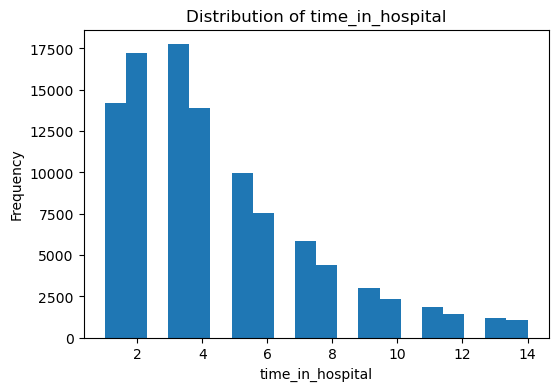

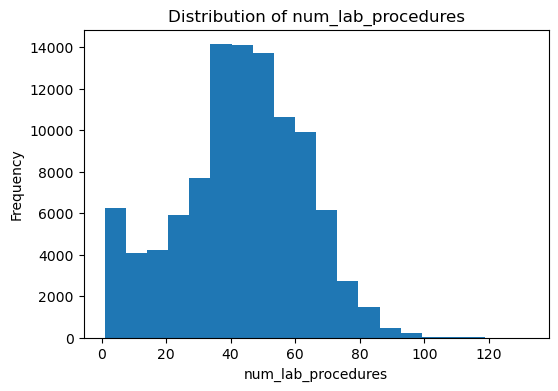

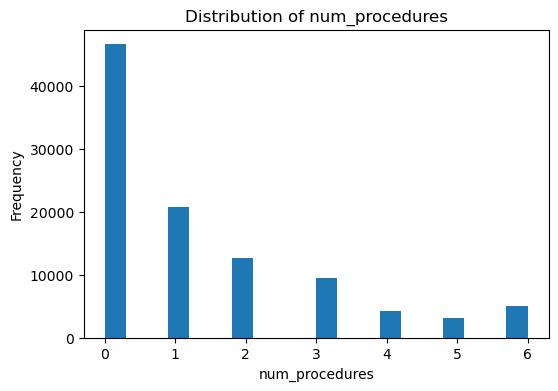

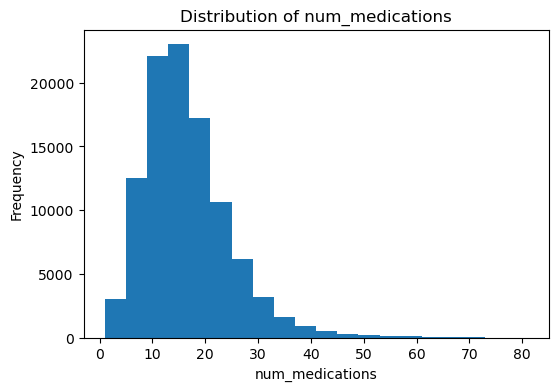

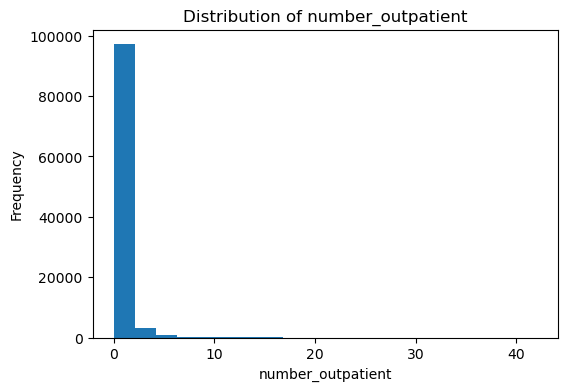

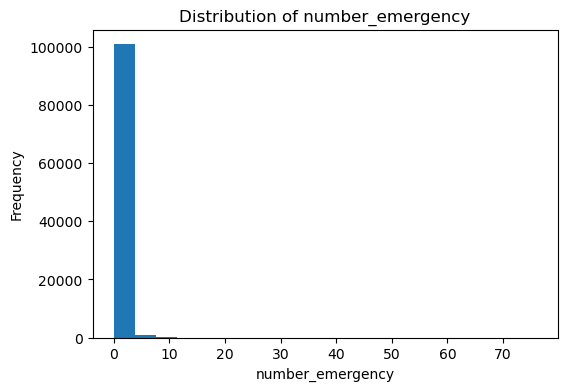

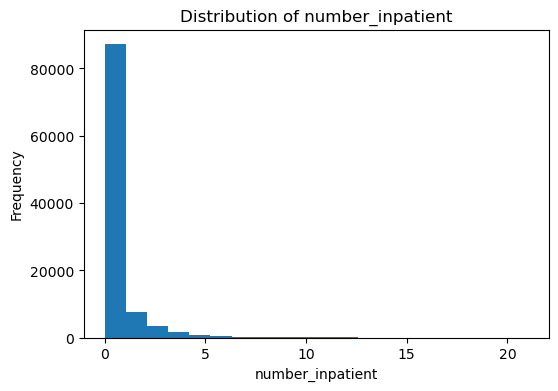

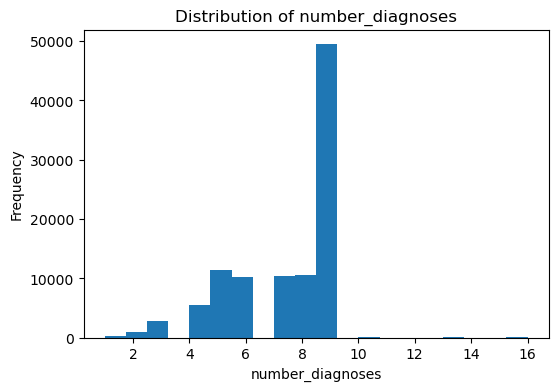

In [78]:
import matplotlib.pyplot as plt

numerical_vars = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

for col in numerical_vars:
    plt.figure(figsize=(6, 4))
    plt.hist(df_model[col], bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### Interpretation of Numerical Distributions

The numerical variables show different distributional patterns.

- `time_in_hospital` is positively skewed. Most hospital stays are relatively short, with fewer encounters lasting close to the maximum of 14 days.
- `num_lab_procedures` is concentrated mainly around 30–70 procedures, although a small number of encounters have very high numbers of laboratory procedures.
- `num_procedures` is strongly concentrated at low values, with many encounters having no procedures or only one procedure.
- `num_medications` is positively skewed. Most encounters involve approximately 10–25 medications, while a small number involve substantially more.
- `number_outpatient`, `number_emergency`, and `number_inpatient` are highly right-skewed. Most encounters have zero or very few previous visits, while a small number of patients have unusually high healthcare utilisation.
- `number_diagnoses` is concentrated mainly between approximately 5 and 9 diagnoses, with comparatively few observations at the extreme values.

Overall, several healthcare-utilisation variables contain extreme values and strong positive skewness. These observations will be considered further when assessing unusual observations and potential outliers.

## 35. Part B - Question 2: Distribution of Categorical Variables

The distributions of the main categorical variables are examined using frequency tables and bar charts. This helps identify dominant categories, rare groups, and any unusual patterns before modelling.

In [79]:
categorical_eda = [
    "gender",
    "age",
    "race",
    "admission_type_group",
    "discharge_group",
    "admission_source_group",
    "diag_1_group",
    "medical_specialty_group"
]

In [80]:
for col in categorical_eda:
    print(f"\n{col}")
    print(df_model[col].value_counts())


gender
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

age
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

race
race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

admission_type_group
admission_type_group
Emergency    53990
Elective     18869
Urgent       18480
Unknown      10396
Other           31
Name: count, dtype: int64

discharge_group
discharge_group
Home                 60234
Transfer/Facility    20901
Home Health          12902
Unknown               4680
Expired               1652
Hospice                771
Other                  626
Name: count, dtype: int64

admission_source_group
admission_source_group
Emergency Room       57

In [81]:
df_model["race"].value_counts()

race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [82]:
df_model["medical_specialty_group"].value_counts()

medical_specialty_group
Unknown                       49949
InternalMedicine              14635
Other                          8340
Emergency/Trauma               7565
Family/GeneralPractice         7440
Cardiology                     5352
Surgery-General                3099
Nephrology                     1613
Orthopedics                    1400
Orthopedics-Reconstructive     1233
Radiologist                    1140
Name: count, dtype: int64

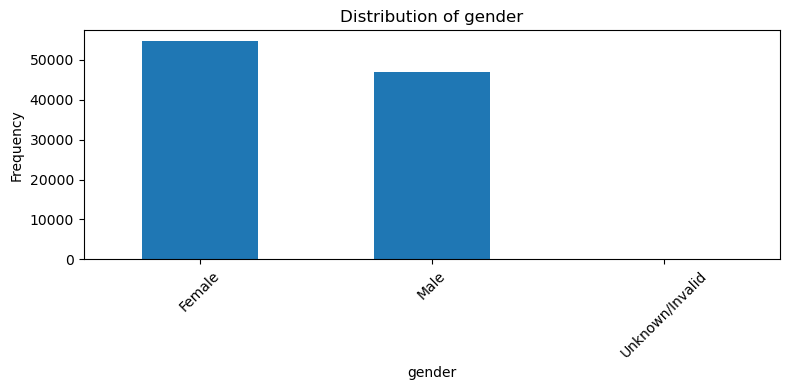

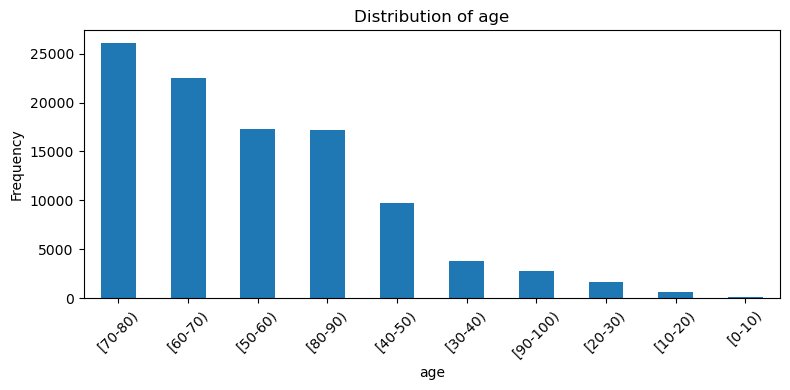

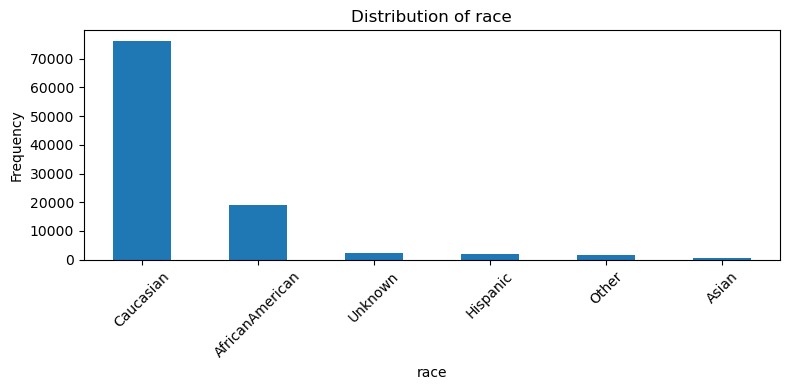

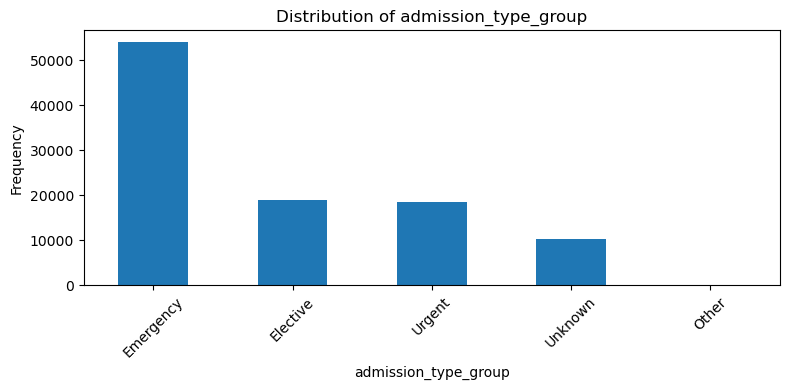

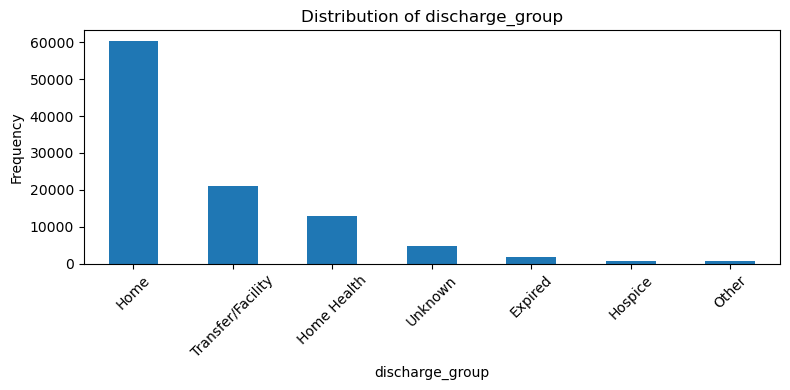

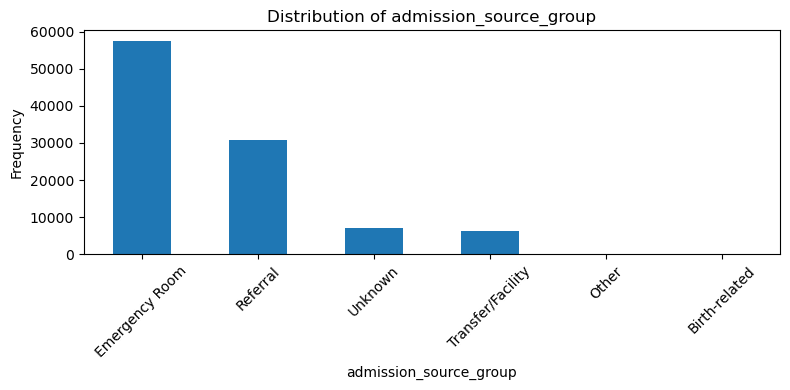

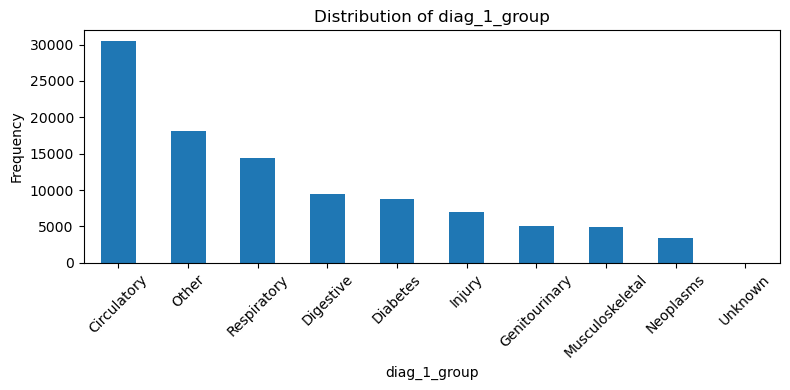

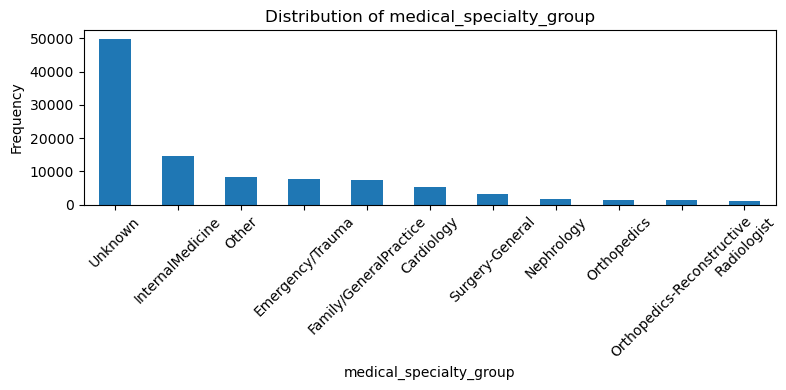

In [83]:
for col in categorical_eda:
    plt.figure(figsize=(8, 4))
    df_model[col].value_counts().plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Interpretation of Categorical Distributions

The categorical variables show several clear patterns. The gender distribution is relatively balanced, while the age distribution is concentrated mainly among older patients, particularly those aged 50–90 years. The race variable is dominated by the Caucasian category. Emergency-related admission categories are common, while several discharge and admission-source categories occur much less frequently. The grouped diagnosis and medical-specialty variables also show clear concentration in a smaller number of common categories.

These patterns indicate that some categorical predictors are unevenly distributed, which should be considered when interpreting model results.

## 36. Part B - Question 3: Relationship Between Predictors and 30-Day Readmission

The relationships between selected predictors and the binary response variable `readmit_30` are examined using graphical and numerical summaries. This helps identify variables that may be associated with early hospital readmission.

In [84]:
age_readmission = (
    df_model.groupby("age")["readmit_30"]
    .mean()
    .sort_index() * 100
)

age_readmission

age
[0-10)       1.863354
[10-20)      5.788712
[20-30)     14.242607
[30-40)     11.231788
[40-50)     10.604027
[50-60)      9.666203
[60-70)     11.128408
[70-80)     11.773055
[80-90)     12.083503
[90-100)    11.099177
Name: readmit_30, dtype: float64

### Age and 30-Day Readmission

The 30-day readmission rate varies across age groups. The highest observed rate was approximately 14.2% among patients aged 20–30 years. Several older age groups, particularly those aged 70–90 years, also showed readmission rates above the overall rate of approximately 11.2%.

However, the relationship between age and readmission does not appear to be strictly increasing with age. Some younger age groups contain substantially fewer observations, so differences in their readmission percentages should be interpreted cautiously.

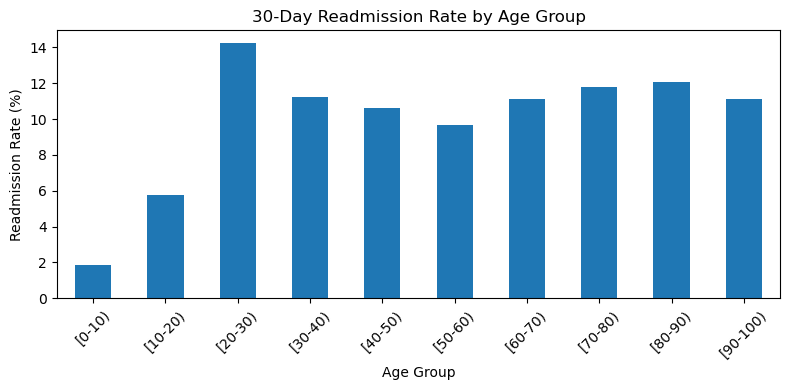

In [85]:
age_readmission.plot(kind="bar", figsize=(8, 4))

plt.title("30-Day Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [86]:
inpatient_readmission = (
    df_model.groupby("number_inpatient")["readmit_30"]
    .mean() * 100
)

inpatient_readmission

number_inpatient
0       8.437084
1      12.924543
2      17.433254
3      20.287306
4      23.612824
5      31.403941
6      34.583333
7      35.447761
8      44.370861
9      42.342342
10     42.622951
11     67.346939
12     50.000000
13     50.000000
14     40.000000
15    100.000000
16     33.333333
17    100.000000
18      0.000000
19     50.000000
21    100.000000
Name: readmit_30, dtype: float64

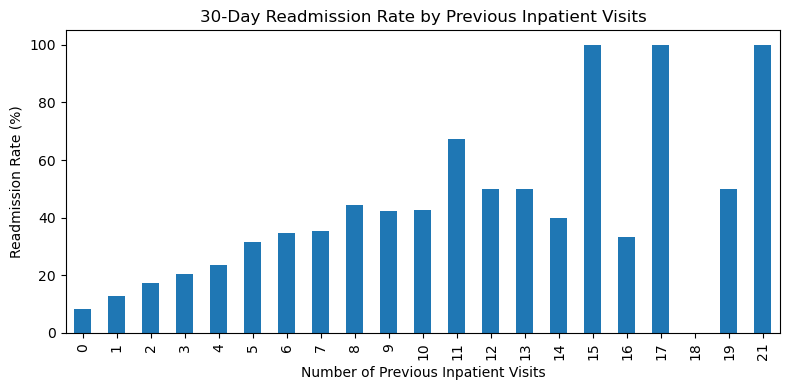

In [87]:
inpatient_readmission.plot(kind="bar", figsize=(8, 4))

plt.title("30-Day Readmission Rate by Previous Inpatient Visits")
plt.xlabel("Number of Previous Inpatient Visits")
plt.ylabel("Readmission Rate (%)")
plt.tight_layout()
plt.show()

## 37. Part B - Question 3: Previous Inpatient Visits and 30-Day Readmission

The relationship between previous inpatient utilisation and 30-day readmission is examined using both group counts and readmission rates. This allows high readmission percentages in very small groups to be interpreted cautiously.

In [88]:
inpatient_summary = (
    df_model.groupby("number_inpatient")["readmit_30"]
    .agg(
        Count="count",
        Readmitted="sum",
        Readmission_Rate="mean"
    )
)

inpatient_summary["Readmission_Rate"] *= 100

inpatient_summary

,Count,Readmitted,Readmission_Rate
number_inpatient,,,
0,67630,5706,8.437084
1,19521,2523,12.924543
2,7566,1319,17.433254
3,3411,692,20.287306
4,1622,383,23.612824
5,812,255,31.403941
6,480,166,34.583333
7,268,95,35.447761
8,151,67,44.370861


## 38. Part B - Question 3: Previous Emergency Visits and 30-Day Readmission

In [89]:
emergency_summary = (
    df_model.groupby("number_emergency")["readmit_30"]
    .agg(
        Count="count",
        Readmitted="sum",
        Readmission_Rate="mean"
    )
)

emergency_summary["Readmission_Rate"] *= 100

emergency_summary

,Count,Readmitted,Readmission_Rate
number_emergency,,,
0,90383,9467,10.474315
1,7677,1102,14.354566
2,2042,373,18.266405
3,725,147,20.275862
4,374,115,30.748663
5,192,47,24.479167
6,94,22,23.404255
7,73,19,26.027397
8,50,16,32.000000


### Interpretation

The 30-day readmission rate increased markedly with the number of previous inpatient visits. Patients with no previous inpatient visits had a readmission rate of approximately 8.4%, compared with rates above 30% among patients with five or more previous inpatient visits.

The very high readmission rates observed for the largest values of `number_inpatient` should be interpreted cautiously because these categories contain very few observations. Overall, previous inpatient utilisation appears to be a potentially important predictor of 30-day readmission.

### Interpretation

The 30-day readmission rate generally increased with the number of previous emergency visits. Encounters with no previous emergency visits had a readmission rate of approximately 10.5%, compared with approximately 18.3% for two previous emergency visits and 30.7% for four previous emergency visits.

At higher values of `number_emergency`, the readmission rates fluctuate substantially because the number of observations in these groups is very small. Therefore, these extreme percentages should be interpreted cautiously. Overall, previous emergency utilisation appears to be associated with increased risk of 30-day readmission.

## 39. Part B - Question 3: Time in Hospital and 30-Day Readmission

The relationship between length of hospital stay and 30-day readmission is examined by calculating the number of encounters, number of early readmissions, and readmission rate for each length of stay.

In [90]:
hospital_stay_summary = (
    df_model.groupby("time_in_hospital")["readmit_30"]
    .agg(
        Count="count",
        Readmitted="sum",
        Readmission_Rate="mean"
    )
)

hospital_stay_summary["Readmission_Rate"] *= 100

hospital_stay_summary

,Count,Readmitted,Readmission_Rate
time_in_hospital,,,
1,14208,1162,8.178491
2,17224,1712,9.939619
3,17756,1894,10.666817
4,13924,1644,11.806952
5,9966,1199,12.030905
6,7539,949,12.587876
7,5859,752,12.834955
8,4391,625,14.233660
9,3002,412,13.724184


### Interpretation

The 30-day readmission rate generally increased as the length of hospital stay increased. Encounters lasting one day had a readmission rate of approximately 8.2%, compared with rates of approximately 12–14% among many encounters lasting five to ten days.

The relationship was not perfectly monotonic, particularly for longer stays, but the overall pattern suggests that longer hospitalisation may be associated with a greater likelihood of early readmission. This may reflect greater illness severity or more complex clinical needs among patients requiring longer hospital stays.

## 40. Part B - Question 3: Number of Medications and 30-Day Readmission

The relationship between the number of medications prescribed during the hospital encounter and 30-day readmission is examined using group counts and readmission rates.

In [91]:
medication_summary = (
    df_model.groupby("num_medications")["readmit_30"]
    .agg(
        Count="count",
        Readmitted="sum",
        Readmission_Rate="mean"
    )
)

medication_summary["Readmission_Rate"] *= 100

medication_summary

,Count,Readmitted,Readmission_Rate
num_medications,,,
1,262,11,4.198473
2,470,39,8.297872
3,900,65,7.222222
4,1417,114,8.045166
5,2017,150,7.436787
...,...,...,...
72,3,3,100.000000
74,1,0,0.000000
75,2,0,0.000000


### Grouping Number of Medications

Because the number of medications has many distinct values and very small sample sizes at the extreme values, medication counts are grouped into broader ranges to obtain more stable and interpretable readmission rates.

In [92]:
df_model["medication_group"] = pd.cut(
    df_model["num_medications"],
    bins=[0, 10, 20, 30, 40, float("inf")],
    labels=["1-10", "11-20", "21-30", "31-40", "41+"]
)

medication_group_summary = (
    df_model.groupby("medication_group", observed=False)["readmit_30"]
    .agg(
        Count="count",
        Readmitted="sum",
        Readmission_Rate="mean"
    )
)

medication_group_summary["Readmission_Rate"] *= 100

medication_group_summary

,Count,Readmitted,Readmission_Rate
medication_group,,,
1-10,25861,2344,9.063841
11-20,52025,5962,11.459875
21-30,18643,2400,12.873465
31-40,3876,497,12.822497
41+,1361,154,11.315209


### Interpretation

The 30-day readmission rate generally increased as the number of medications increased. Encounters involving 1–10 medications had a readmission rate of approximately 9.1%, compared with approximately 12.9% among encounters involving 21–30 medications.

The readmission rate remained similar for the 31–40 medication group and decreased slightly among encounters involving more than 40 medications. Therefore, the relationship is not strictly linear, although patients receiving larger numbers of medications generally showed higher readmission rates than those receiving fewer medications.

## 41. Part B - Question 3: Primary Diagnosis Group and 30-Day Readmission

The relationship between the grouped primary diagnosis and 30-day readmission is examined by calculating the number of encounters, number of early readmissions, and readmission rate for each diagnostic category.

In [93]:
diagnosis_summary = (
    df_model.groupby("diag_1_group")["readmit_30"]
    .agg(
        Count="count",
        Readmitted="sum",
        Readmission_Rate="mean"
    )
)

diagnosis_summary["Readmission_Rate"] *= 100

diagnosis_summary.sort_values(
    "Readmission_Rate",
    ascending=False
)

,Count,Readmitted,Readmission_Rate
diag_1_group,,,
Unknown,21,5,23.809524
Diabetes,8757,1137,12.983899
Injury,6974,854,12.245483
Other,18172,2086,11.479199
Circulatory,30437,3485,11.449880
Genitourinary,5117,555,10.846199
Digestive,9475,1015,10.712401
Neoplasms,3433,346,10.078648
Respiratory,14423,1403,9.727519


### Interpretation

The 30-day readmission rate varied across primary diagnosis groups. Among the well-represented categories, encounters with a primary diagnosis grouped as Diabetes showed the highest readmission rate at approximately 13.0%, followed by Injury at approximately 12.2%.

Circulatory and Other diagnoses had readmission rates close to the overall average, while Respiratory and Musculoskeletal diagnoses showed comparatively lower rates.

The Unknown category had a high observed readmission rate, but it contained only 21 encounters and therefore should be interpreted cautiously. Overall, primary diagnosis group appears to have some association with 30-day readmission, although the differences are less pronounced than those observed for previous inpatient utilisation.

## 42. Part B - Question 3: Insulin Treatment and 30-Day Readmission

The relationship between insulin treatment status and 30-day readmission is examined by comparing the readmission rate across the insulin categories recorded during the hospital encounter.

In [94]:
insulin_summary = (
    df_model.groupby("insulin")["readmit_30"]
    .agg(
        Count="count",
        Readmitted="sum",
        Readmission_Rate="mean"
    )
)

insulin_summary["Readmission_Rate"] *= 100

insulin_summary.sort_values(
    "Readmission_Rate",
    ascending=False
)

,Count,Readmitted,Readmission_Rate
insulin,,,
Down,12218,1698,13.897528
Up,11316,1470,12.990456
Steady,30849,3433,11.128400
No,47383,4756,10.037355


### Interpretation

The 30-day readmission rate differed across insulin treatment categories. Encounters in which insulin was decreased had the highest readmission rate at approximately 13.9%, followed by encounters in which insulin was increased at approximately 13.0%.

Patients whose insulin treatment remained steady had a readmission rate of approximately 11.1%, while those with no recorded insulin treatment had the lowest rate at approximately 10.0%.

This suggests that changes in insulin treatment may be associated with a greater likelihood of 30-day readmission. However, this association does not establish that changing insulin causes readmission; treatment changes may instead reflect greater disease complexity or clinical instability.

## 43. Part B - Question 4: Influential Observations, Outliers, and Unusual Patterns

Potential outliers and unusual observations are examined in the numerical variables using summary statistics and boxplots. Particular attention is given to highly skewed healthcare-utilisation variables, where extreme values may represent genuine high-use patients rather than data-entry errors.

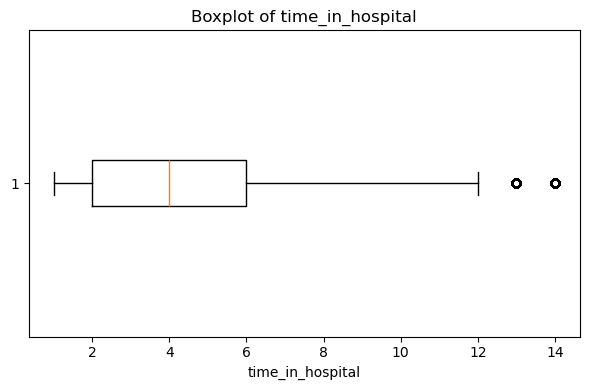

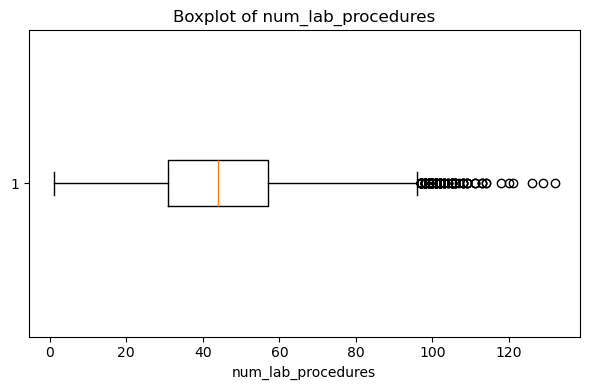

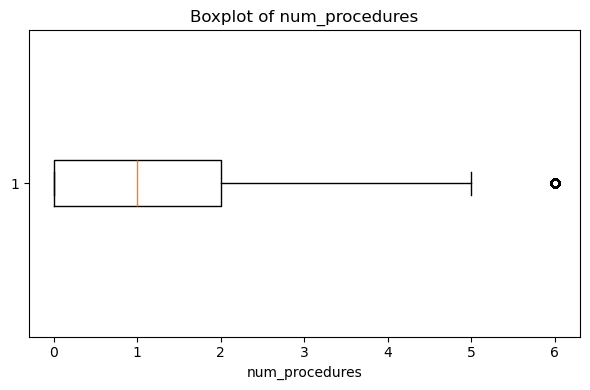

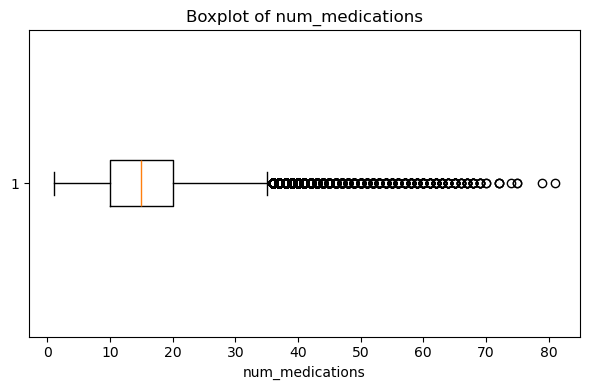

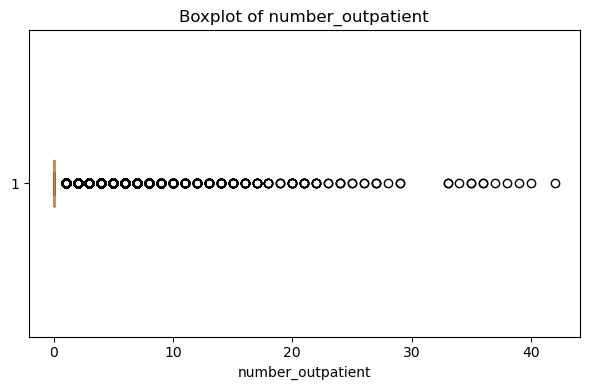

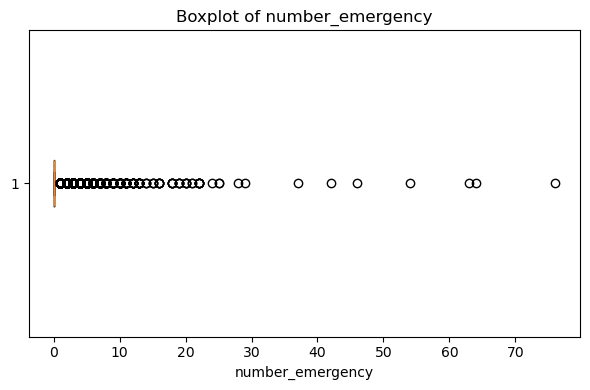

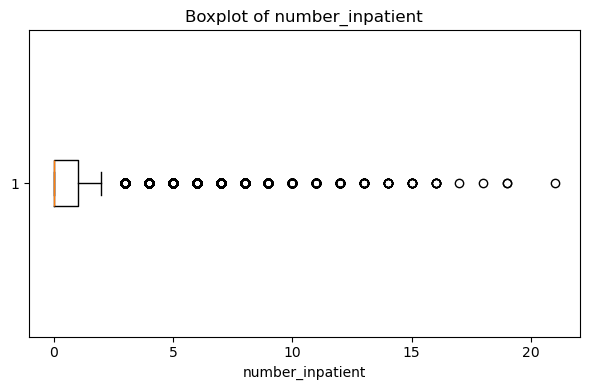

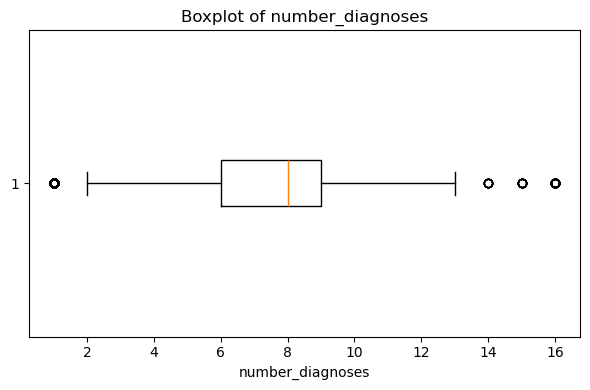

In [95]:
for col in numerical_vars:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df_model[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

### Interpretation of Outliers and Unusual Patterns

The boxplots indicate the presence of several potential outliers among the numerical variables.

- `time_in_hospital` shows a small number of longer stays, particularly around 13–14 days.
- `num_lab_procedures` contains several unusually high values, including encounters with more than approximately 100 laboratory procedures.
- `num_procedures` is concentrated at low values, with the maximum value of 6 appearing as an upper outlier.
- `num_medications` contains a relatively long upper tail, with some encounters involving substantially more medications than the majority of observations.
- `number_outpatient`, `number_emergency`, and `number_inpatient` are strongly right-skewed and contain many high-value observations. These may represent patients with unusually high previous healthcare utilisation.
- `number_diagnoses` is concentrated mainly around 6–9 diagnoses, with a small number of observations at both the lower and upper extremes.

These observations were not automatically removed because they are plausible within a hospital dataset and may contain important information about patients with complex healthcare needs. Their influence on model performance will therefore be assessed during modelling.

## 44. Part B - Question 5: Expected Important Predictors

Based on the exploratory data analysis, two predictors are identified as potentially important for predicting 30-day readmission. These selections are based on the observed differences in readmission rates across predictor levels.

### Expected Important Predictors

1. **Previous inpatient visits (`number_inpatient`)**  
   The 30-day readmission rate increased substantially as the number of previous inpatient visits increased. Encounters with no previous inpatient visits had a readmission rate of approximately 8.4%, while rates exceeded 30% among patients with five or more previous inpatient visits. This suggests that prior inpatient utilisation may be a strong predictor of early readmission.

2. **Previous emergency visits (`number_emergency`)**  
   The readmission rate also generally increased with the number of previous emergency visits. Encounters with no previous emergency visits had a readmission rate of approximately 10.5%, compared with higher rates among patients with several previous emergency visits. Although the relationship was less consistent at extreme values because of small group sizes, the overall pattern suggests that prior emergency healthcare utilisation may also be predictive of early readmission.

## 45. Part B - Question 6: Splitting the Data into Training and Test Sets

The cleaned dataset is divided into training and test sets using an 80:20 ratio. The training set will be used to fit and tune the models, while the test set will be reserved for evaluating predictive performance on unseen data.

In [96]:
X = df_model.drop(columns=["readmit_30"])
y = df_model["readmit_30"]

In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [98]:
stratify=y

In [99]:
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set: (81412, 29)
Test set: (20354, 29)

Training target distribution:
readmit_30
0    88.839483
1    11.160517
Name: proportion, dtype: float64

Test target distribution:
readmit_30
0    88.842488
1    11.157512
Name: proportion, dtype: float64


In [100]:
X = df_model.drop(
    columns=["readmit_30", "medication_group"]
)

y = df_model["readmit_30"]

In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [102]:
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set: (81412, 28)
Test set: (20354, 28)

Training target distribution:
readmit_30
0    88.839483
1    11.160517
Name: proportion, dtype: float64

Test target distribution:
readmit_30
0    88.842488
1    11.157512
Name: proportion, dtype: float64


### Interpretation

The cleaned dataset was divided into 80% training data and 20% test data using stratified random sampling. The 30-day readmission class represented approximately 11.2% of observations in both the training and test sets. Therefore, the original class imbalance was successfully preserved in both subsets.

The training data will be used for model development and tuning, while the test data will remain separate for final evaluation of predictive performance.

## 46. Part C - Question 1: Preparing Predictors for Logistic Regression

The predictor set contains both numerical and categorical variables. Categorical variables are converted into dummy variables using one-hot encoding so that they can be included in the binary logistic regression model. The encoding is fitted using the training data and then applied consistently to the test data.

In [103]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numerical_cols = X_train.select_dtypes(exclude="object").columns.tolist()

print("Numerical predictors:", len(numerical_cols))
print("Categorical predictors:", len(categorical_cols))

Numerical predictors: 8
Categorical predictors: 20


In [104]:
df_model.to_csv(
    "data/cleaned_diabetes_data.csv",
    index=False
)

In [105]:
print(df_model.shape)

(101766, 30)


## 46. Saving the Final Cleaned Modelling Dataset

A final cleaned dataset is saved before modelling. The temporary `medication_group` variable, which was created only for exploratory analysis, is excluded. The original numerical variable `num_medications` is retained for modelling.

In [106]:
df_final = df_model.drop(columns=["medication_group"])

print(df_final.shape)

(101766, 29)


In [107]:
df_final.to_csv(
    "data/cleaned_diabetes_data.csv",
    index=False
)

In [108]:
X = df_final.drop(columns=["readmit_30"])
y = df_final["readmit_30"]

## 47. Part C - Question 1: Defining Predictors and Response

The final cleaned dataset is separated into predictor variables (`X`) and the binary response variable (`y`). The response variable `readmit_30` indicates whether a patient was readmitted within 30 days.

In [109]:
X = df_final.drop(columns=["readmit_30"])
y = df_final["readmit_30"]

print(X.shape)
print(y.shape)

(101766, 28)
(101766,)


In [110]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (81412, 28)
Test set: (20354, 28)


## 48. Part C - Question 1: One-Hot Encoding of Categorical Predictors

Categorical predictors cannot be entered directly into the logistic regression model in text form. Therefore, one-hot encoding is used to convert each category into binary indicator variables. One category from each variable is omitted to act as the reference category and to avoid perfect multicollinearity.

In [111]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numerical_cols = X_train.select_dtypes(exclude="object").columns.tolist()

print("Categorical predictors:", len(categorical_cols))
print("Numerical predictors:", len(numerical_cols))

Categorical predictors: 20
Numerical predictors: 8


In [112]:
X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [113]:
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

In [114]:
print("Encoded training set:", X_train_encoded.shape)
print("Encoded test set:", X_test_encoded.shape)

Encoded training set: (81412, 102)
Encoded test set: (20354, 102)


## 49. Part C - Question 1: Excluding Patients Who Expired

Patients recorded as `Expired` at discharge are excluded from the modelling population because they are not at risk of subsequent hospital readmission. Including these encounters could create an artificial predictive relationship with the 30-day readmission outcome.

In [115]:
# Keep only patients who did not expire
train_mask = X_train["discharge_group"] != "Expired"
test_mask = X_test["discharge_group"] != "Expired"

X_train = X_train.loc[train_mask]
y_train = y_train.loc[train_mask]

X_test = X_test.loc[test_mask]
y_test = y_test.loc[test_mask]

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (80077, 28)
Test set: (20037, 28)


In [116]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

print("Encoded training set:", X_train_encoded.shape)
print("Encoded test set:", X_test_encoded.shape)

Encoded training set: (80077, 101)
Encoded test set: (20037, 101)


## 50. Part C - Question 1: Full Binary Logistic Regression Model

A full binary logistic regression model is fitted using all encoded predictors in the training data. The response variable is `readmit_30`, where 1 indicates readmission within 30 days and 0 indicates no readmission within 30 days.

In [117]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train_encoded)

logit_full = sm.Logit(y_train, X_train_sm)

result_full = logit_full.fit()

print(result_full.summary())

         Current function value: 0.337172
         Iterations: 35


c:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                           Logit Regression Results                           
Dep. Variable:             readmit_30   No. Observations:                80077
Model:                          Logit   Df Residuals:                    79975
Method:                           MLE   Df Model:                          101
Date:                Tue, 29 Sep 2026   Pseudo R-squ.:                 0.04673
Time:                        23:32:20   Log-Likelihood:                -27000.
converged:                      False   LL-Null:                       -28323.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------
const                                                -54.4073    5.3e+05     -0.000      1.000   -1.04e+06    1.04e+06
time_in_hos

In [118]:
result_full = logit_full.fit(maxiter=200)

print(result_full.summary())

         Current function value: 0.337172
         Iterations: 200


c:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                           Logit Regression Results                           
Dep. Variable:             readmit_30   No. Observations:                80077
Model:                          Logit   Df Residuals:                    79975
Method:                           MLE   Df Model:                          101
Date:                Tue, 29 Sep 2026   Pseudo R-squ.:                 0.04673
Time:                        23:32:37   Log-Likelihood:                -27000.
converged:                      False   LL-Null:                       -28323.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------
const                                                -54.4073   6.16e+05  -8.84e-05      1.000   -1.21e+06    1.21e+06
time_in_hos

In [119]:
pd.crosstab(
    X_train["admission_source_group"],
    y_train
)

readmit_30,0,1
admission_source_group,,
Birth-related,3,0
Emergency Room,39846,5393
Other,7,1
Referral,21735,2595
Transfer/Facility,4487,500
Unknown,4913,597


In [120]:
X_train["admission_source_group"] = X_train["admission_source_group"].replace(
    ["Birth-related", "Other"],
    "Unknown"
)

X_test["admission_source_group"] = X_test["admission_source_group"].replace(
    ["Birth-related", "Other"],
    "Unknown"
)

In [121]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

print("Encoded training set:", X_train_encoded.shape)
print("Encoded test set:", X_test_encoded.shape)

Encoded training set: (80077, 99)
Encoded test set: (20037, 99)


In [122]:
X_train_sm = sm.add_constant(X_train_encoded)

logit_full = sm.Logit(y_train, X_train_sm)

result_full = logit_full.fit(maxiter=200)

print(result_full.summary())

c:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


         Current function value: 0.337175
         Iterations: 200


LinAlgError: Singular matrix

In [ ]:
dummy_counts = X_train_encoded.sum().sort_values()

print(dummy_counts.head(20))

gender_Unknown/Invalid                                   3
diag_1_group_Unknown                                    13
admission_type_group_Other                              24
repaglinide_Up                                          84
rosiglitazone_Up                                       134
pioglitazone_Up                                        183
glimepiride_Up                                         263
diag_2_group_Unknown                                   281
race_Asian                                             511
discharge_group_Other                                  517
age_[10-20)                                            560
glipizide_Up                                           602
discharge_group_Hospice                                611
glyburide_Up                                           653
metformin_Up                                           840
medical_specialty_group_Radiologist                    898
medical_specialty_group_Orthopedics-Reconstructive    10

In [126]:
# Remove the 3 training rows with invalid/unknown gender
train_mask = X_train["gender"] != "Unknown/Invalid"
X_train = X_train.loc[train_mask]
y_train = y_train.loc[train_mask]

# Remove any equivalent cases from the test set
test_mask = X_test["gender"] != "Unknown/Invalid"
X_test = X_test.loc[test_mask]
y_test = y_test.loc[test_mask]

# Merge very rare diagnosis category
X_train["diag_1_group"] = X_train["diag_1_group"].replace("Unknown", "Other")
X_test["diag_1_group"] = X_test["diag_1_group"].replace("Unknown", "Other")

# Merge very rare admission-type category
X_train["admission_type_group"] = X_train["admission_type_group"].replace(
    "Other", "Unknown"
)

X_test["admission_type_group"] = X_test["admission_type_group"].replace(
    "Other", "Unknown"
)

In [127]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

print("Encoded training set:", X_train_encoded.shape)
print("Encoded test set:", X_test_encoded.shape)

Encoded training set: (80074, 96)
Encoded test set: (20037, 96)


In [ ]:
X_train_sm = sm.add_constant(X_train_encoded)

logit_full = sm.Logit(y_train, X_train_sm)

result_full = logit_full.fit(maxiter=200)

print(result_full.summary())

Optimization terminated successfully.
         Current function value: 0.337212
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:             readmit_30   No. Observations:                80074
Model:                          Logit   Df Residuals:                    79977
Method:                           MLE   Df Model:                           96
Date:                Sat, 26 Sep 2026   Pseudo R-squ.:                 0.04664
Time:                        18:12:28   Log-Likelihood:                -27002.
converged:                       True   LL-Null:                       -28323.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------
const                       

In [ ]:
results_table = pd.DataFrame({
    "Coefficient": result_full.params,
    "P_value": result_full.pvalues
})

results_table = results_table.drop(index="const")

results_table = results_table.sort_values("P_value")

results_table.head(15)

,Coefficient,P_value
number_inpatient,0.261177,2.992461e-271
discharge_group_Transfer/Facility,0.578037,6.251137e-80
diag_1_group_Respiratory,-0.254524,1.664962e-10
discharge_group_Home Health,0.214058,2.988210e-09
discharge_group_Unknown,0.311014,1.807991e-08
diag_2_group_Neoplasms,0.377220,3.985889e-07
discharge_group_Hospice,-0.780535,1.053648e-05
number_diagnoses,0.033624,1.058038e-05
diabetesMed_Yes,0.169736,7.613227e-05
medical_specialty_group_Nephrology,0.395843,1.033346e-04


## 51. Part C - Question 2: Most Statistically Significant Predictors

The three terms with the smallest p-values in the full logistic regression model were `number_inpatient`, `discharge_group_Transfer/Facility`, and `diag_1_group_Respiratory`.

- **number_inpatient:** The coefficient was positive, indicating that patients with a greater number of previous inpatient visits had higher odds of 30-day readmission, after controlling for the other predictors.
- **discharge_group_Transfer/Facility:** The positive coefficient indicates higher odds of 30-day readmission for patients discharged to another facility compared with the reference discharge category.
- **diag_1_group_Respiratory:** The negative coefficient indicates lower odds of 30-day readmission for encounters with a respiratory primary diagnosis compared with the reference diagnosis category.

All three terms were statistically significant with p-values well below 0.05. These results describe associations and should not be interpreted as causal effects.

## 52. Part C - Question 2: Odds Ratios for Important Predictors

Logistic regression coefficients are expressed on the log-odds scale. To make them easier to interpret, the coefficients are exponentiated to obtain odds ratios.

In [ ]:
important_predictors = [
    "number_inpatient",
    "discharge_group_Transfer/Facility",
    "diag_1_group_Respiratory"
]

odds_ratios = np.exp(result_full.params[important_predictors])

odds_ratios

number_inpatient                     1.298457
discharge_group_Transfer/Facility    1.782536
diag_1_group_Respiratory             0.775285
dtype: float64

### Interpretation

The odds ratio for `number_inpatient` was 1.298, indicating that each additional previous inpatient visit was associated with approximately 29.8% higher odds of 30-day readmission.

The odds ratio for `discharge_group_Transfer/Facility` was 1.783, indicating approximately 78.3% higher odds of 30-day readmission compared with the reference discharge category.

The odds ratio for `diag_1_group_Respiratory` was 0.775, indicating approximately 22.5% lower odds of 30-day readmission compared with the reference diagnosis category.

## 53. Part C - Question 2: Confirming Reference Categories

For categorical predictors represented by dummy variables, each coefficient is interpreted relative to an omitted reference category. The reference categories are therefore identified before interpreting the odds ratios.

In [124]:
print("Discharge categories:")
print(sorted(X_train["discharge_group"].unique()))

print("\nDischarge dummy columns:")
print([
    col for col in X_train_encoded.columns
    if col.startswith("discharge_group_")
])

print("\nDiagnosis categories:")
print(sorted(X_train["diag_1_group"].unique()))

print("\nDiagnosis dummy columns:")
print([
    col for col in X_train_encoded.columns
    if col.startswith("diag_1_group_")
])

Discharge categories:
['Home', 'Home Health', 'Hospice', 'Other', 'Transfer/Facility', 'Unknown']

Discharge dummy columns:
['discharge_group_Home Health', 'discharge_group_Hospice', 'discharge_group_Other', 'discharge_group_Transfer/Facility', 'discharge_group_Unknown']

Diagnosis categories:
['Circulatory', 'Diabetes', 'Digestive', 'Genitourinary', 'Injury', 'Musculoskeletal', 'Neoplasms', 'Other', 'Respiratory', 'Unknown']

Diagnosis dummy columns:
['diag_1_group_Diabetes', 'diag_1_group_Digestive', 'diag_1_group_Genitourinary', 'diag_1_group_Injury', 'diag_1_group_Musculoskeletal', 'diag_1_group_Neoplasms', 'diag_1_group_Other', 'diag_1_group_Respiratory', 'diag_1_group_Unknown']


- Patients discharged to a transfer/facility had approximately 78.3% higher odds of 30-day readmission compared with patients discharged home, holding the other predictors constant.

- Patients whose primary diagnosis was Respiratory had approximately 22.5% lower odds of 30-day readmission compared with patients whose primary diagnosis was Circulatory, holding the other predictors constant.

## 54. Part C - Question 3: Reduced Logistic Regression Using Backward Elimination

A backward elimination procedure was used to obtain a reduced logistic regression model. The procedure begins with the full model and sequentially removes the predictor with the largest p-value greater than 0.05. The model is refitted after each removal until all remaining terms are statistically significant at the 5% level.

In [128]:
def backward_elimination(X, y, significance_level=0.05):
    X_selected = X.copy()

    while True:
        X_with_const = sm.add_constant(X_selected)

        model = sm.Logit(
            y,
            X_with_const
        ).fit(
            maxiter=200,
            disp=False
        )

        pvalues = model.pvalues.drop("const")
        max_pvalue = pvalues.max()

        if max_pvalue > significance_level:
            worst_feature = pvalues.idxmax()
            X_selected = X_selected.drop(columns=[worst_feature])
        else:
            break

    return X_selected, model


X_train_reduced, result_reduced = backward_elimination(
    X_train_encoded,
    y_train
)

print("Number of predictors in full model:", X_train_encoded.shape[1])
print("Number of predictors in reduced model:", X_train_reduced.shape[1])
print("Reduced model converged:", result_reduced.mle_retvals["converged"])

Number of predictors in full model: 96
Number of predictors in reduced model: 45
Reduced model converged: True


In [129]:
retained_predictors = X_train_reduced.columns.tolist()

print("Retained predictors:")
for predictor in retained_predictors:
    print(predictor)

Retained predictors:
num_medications
number_emergency
number_inpatient
number_diagnoses
race_Unknown
age_[20-30)
age_[30-40)
age_[40-50)
age_[50-60)
age_[60-70)
age_[70-80)
age_[80-90)
age_[90-100)
metformin_Steady
metformin_Up
glimepiride_Steady
insulin_No
insulin_Steady
insulin_Up
diabetesMed_Yes
diag_1_group_Digestive
diag_1_group_Genitourinary
diag_1_group_Injury
diag_1_group_Musculoskeletal
diag_1_group_Neoplasms
diag_1_group_Other
diag_1_group_Respiratory
diag_2_group_Diabetes
diag_2_group_Neoplasms
diag_3_group_Diabetes
diag_3_group_Genitourinary
diag_3_group_Neoplasms
medical_specialty_group_Family/GeneralPractice
medical_specialty_group_InternalMedicine
medical_specialty_group_Nephrology
medical_specialty_group_Orthopedics
medical_specialty_group_Orthopedics-Reconstructive
medical_specialty_group_Other
medical_specialty_group_Unknown
discharge_group_Home Health
discharge_group_Hospice
discharge_group_Other
discharge_group_Transfer/Facility
discharge_group_Unknown
admission_sou

## 55. Part C - Question 4: Comparing Full and Reduced Logistic Regression Models

The predictive performance of the full and reduced logistic regression models is evaluated using the test data. Because the response variable is imbalanced, several performance measures are considered, including accuracy, precision, recall, F1-score, and ROC-AUC.

In [130]:
X_test_reduced = X_test_encoded[
    X_train_reduced.columns
]

X_test_reduced_sm = sm.add_constant(
    X_test_reduced,
    has_constant="add"
)

In [132]:
X_train_sm = sm.add_constant(
    X_train_encoded,
    has_constant="add"
)

logit_full = sm.Logit(y_train, X_train_sm)

result_full = logit_full.fit(
    maxiter=200
)

print("Converged:", result_full.mle_retvals["converged"])
print("Number of model parameters:", len(result_full.params))

Optimization terminated successfully.
         Current function value: 0.337212
         Iterations 8
Converged: True
Number of model parameters: 97


In [133]:
X_test_full_sm = sm.add_constant(
    X_test_encoded,
    has_constant="add"
)

full_prob = result_full.predict(X_test_full_sm)
reduced_prob = result_reduced.predict(X_test_reduced_sm)

print(full_prob.head())
print(reduced_prob.head())

99195    0.100674
63319    0.074403
64536    0.107969
13039    0.146082
37502    0.159001
dtype: float64
99195    0.102650
63319    0.071348
64536    0.115313
13039    0.135334
37502    0.158370
dtype: float64


In [134]:
full_pred = (full_prob >= 0.5).astype(int)
reduced_pred = (reduced_prob >= 0.5).astype(int)

In [135]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

full_metrics = {
    "Accuracy": accuracy_score(y_test, full_pred),
    "Precision": precision_score(y_test, full_pred),
    "Recall": recall_score(y_test, full_pred),
    "F1 Score": f1_score(y_test, full_pred),
    "ROC-AUC": roc_auc_score(y_test, full_prob)
}

reduced_metrics = {
    "Accuracy": accuracy_score(y_test, reduced_pred),
    "Precision": precision_score(y_test, reduced_pred),
    "Recall": recall_score(y_test, reduced_pred),
    "F1 Score": f1_score(y_test, reduced_pred),
    "ROC-AUC": roc_auc_score(y_test, reduced_prob)
}

print("Full model:", full_metrics)
print("Reduced model:", reduced_metrics)

Full model: {'Accuracy': 0.8866097719219445, 'Precision': 0.49206349206349204, 'Recall': 0.013650374284456186, 'F1 Score': 0.026563838903170524, 'ROC-AUC': 0.6663194006055433}
Reduced model: {'Accuracy': 0.8866097719219445, 'Precision': 0.4918032786885246, 'Recall': 0.013210039630118891, 'F1 Score': 0.025728987993138937, 'ROC-AUC': 0.6654076010297376}


Although both logistic regression models achieved high overall accuracy, their recall for 30-day readmission was very low at the default 0.5 classification threshold. This indicates that the models classified most patients as non-readmitted and failed to identify many actual readmissions. Therefore, accuracy alone is not sufficient for evaluating model performance in this imbalanced dataset.

In [136]:
comparison = pd.DataFrame({
    "Full Model": full_metrics,
    "Reduced Model": reduced_metrics
})

comparison

,Full Model,Reduced Model
Accuracy,0.886610,0.886610
Precision,0.492063,0.491803
Recall,0.013650,0.013210
F1 Score,0.026564,0.025729
ROC-AUC,0.666319,0.665408


### Interpretation

The full and reduced logistic regression models produced almost identical test-set performance.

The full model achieved an accuracy of approximately 88.66%, while the reduced model achieved the same overall accuracy. However, both models had very low recall, identifying only about 1.3% of the actual 30-day readmissions at the default 0.5 classification threshold.

The ROC-AUC values were approximately 0.666 for the full model and 0.665 for the reduced model, indicating that both models had similar ability to distinguish between patients who were and were not readmitted within 30 days.

The reduced model used substantially fewer predictor terms while producing almost the same predictive performance as the full model. Therefore, the reduced model provides a more parsimonious representation without materially reducing predictive performance.

Because the outcome is imbalanced, accuracy alone is not sufficient for evaluating model performance. The very low recall at the 0.5 threshold indicates that threshold adjustment should be considered later when the goal is to identify a larger proportion of patients at risk of 30-day readmission.

## 56. Part C - Question 4: Effect of Classification Threshold

The default classification threshold of 0.5 resulted in very low recall for 30-day readmission. Therefore, alternative classification thresholds are examined to determine how lowering the threshold affects recall, precision, and F1-score.

In [137]:
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

threshold_results = []

for threshold in thresholds:
    pred = (reduced_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

threshold_table = pd.DataFrame(threshold_results)

threshold_table

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.10,0.571642,0.164541,0.681638,0.265091
1,0.15,0.791336,0.220597,0.332012,0.265073
2,0.20,0.856765,0.274643,0.160722,0.202778
3,0.25,0.874832,0.315133,0.088948,0.138736
4,0.30,0.881719,0.362117,0.057244,0.098859
5,0.40,0.885961,0.449275,0.027301,0.051474
6,0.50,0.886610,0.491803,0.013210,0.025729


Lower threshold
→ predicts more patients as readmitted
→ recall usually increases
→ precision and accuracy may decrease

### Interpretation

Reducing the classification threshold substantially increased the model's ability to identify actual 30-day readmissions. At the default threshold of 0.50, recall was only 1.32%, despite an overall accuracy of 88.66%.

At a threshold of 0.10, recall increased to approximately 68.16%, although accuracy decreased to 57.16% and precision was 16.45%. At a threshold of 0.15, recall was approximately 33.20% with an accuracy of 79.13%.

These results demonstrate the trade-off between recall, precision, and overall accuracy when the classification threshold is changed. For a readmission-risk application, a lower threshold may be useful when identifying a larger proportion of potentially high-risk patients is more important than minimizing false-positive classifications. The final choice of threshold should therefore depend on the practical costs of false negatives and false positives.

## 57. Part C - Question 4: Confusion Matrix at Different Classification Thresholds

Confusion matrices are used to examine how the classification threshold affects the numbers of true positives, false positives, true negatives, and false negatives. The default threshold of 0.50 is compared with a lower threshold of 0.10.

In [138]:
from sklearn.metrics import confusion_matrix

# Predictions at threshold 0.50
pred_050 = (reduced_prob >= 0.50).astype(int)

# Predictions at threshold 0.10
pred_010 = (reduced_prob >= 0.10).astype(int)

cm_050 = confusion_matrix(y_test, pred_050)
cm_010 = confusion_matrix(y_test, pred_010)

print("Confusion Matrix - Threshold 0.50")
print(cm_050)

print("\nConfusion Matrix - Threshold 0.10")
print(cm_010)

Confusion Matrix - Threshold 0.50
[[17735    31]
 [ 2241    30]]

Confusion Matrix - Threshold 0.10
[[9906 7860]
 [ 723 1548]]


### Interpretation

At the default threshold of 0.50, the reduced logistic regression model correctly identified only 30 of the 2,271 actual 30-day readmissions, while 2,241 readmissions were missed. This explains the very low recall observed at the default threshold.

When the threshold was reduced to 0.10, the number of correctly identified readmissions increased substantially to 1,548, while the number of missed readmissions decreased to 723. However, the lower threshold also increased the number of false-positive classifications from 31 to 7,860.

Therefore, lowering the classification threshold substantially improves sensitivity to actual readmissions, but at the cost of reduced specificity and a much larger number of false positives.

## 58. Part C - Question 4: Logistic Regression Model Adequacy and Final Assessment

The full logistic regression model initially contained 96 encoded predictor terms, while backward elimination reduced the model to 45 terms. The reduced model converged successfully and produced almost identical predictive performance to the full model.

The full model achieved an ROC-AUC of approximately 0.666, while the reduced model achieved an ROC-AUC of approximately 0.665. This indicates that reducing the number of predictors did not materially reduce the model's ability to distinguish between patients who were and were not readmitted within 30 days.

At the default classification threshold of 0.50, both models achieved approximately 88.66% accuracy. However, recall was very low because the outcome was highly imbalanced and most observations were classified as non-readmitted.

Threshold analysis showed that lowering the classification threshold substantially increased recall. For example, at a threshold of 0.10, the reduced model identified 1,548 of the 2,271 actual readmissions, compared with only 30 at the 0.50 threshold. This improvement in recall was accompanied by a substantial increase in false-positive classifications.

Overall, the reduced logistic regression model provides a more parsimonious model with predictive performance very similar to the full model. However, its classification performance is strongly affected by the chosen threshold, and the trade-off between detecting readmissions and generating false positives should be considered when the model is used in practice.

## 59. Part D - Question 1: Random Forest Classifier

A Random Forest classifier is fitted to predict 30-day hospital readmission. Random Forest is an ensemble learning method that combines many decision trees and aggregates their predictions. It can model nonlinear relationships and interactions between predictors without requiring the same assumptions as logistic regression.

X_train_encoded
X_test_encoded
y_train
y_test

In [139]:
class_weight="balanced"

In [140]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train_encoded, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

RandomForestClassifier(
    class_weight='balanced',
    n_estimators=300,
    n_jobs=-1,
    random_state=42
)

## 60. Part D - Question 1: Random Forest Test-Set Performance

The fitted Random Forest classifier is evaluated using the untouched test data. Performance is assessed using accuracy, precision, recall, F1-score, and ROC-AUC because the response variable is imbalanced.

In [141]:
rf_pred = rf_model.predict(X_test_encoded)
rf_prob = rf_model.predict_proba(X_test_encoded)[:, 1]

rf_metrics = {
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred, zero_division=0),
    "Recall": recall_score(y_test, rf_pred),
    "F1 Score": f1_score(y_test, rf_pred),
    "ROC-AUC": roc_auc_score(y_test, rf_prob)
}

rf_metrics

{'Accuracy': 0.8867594949343715,
 'Precision': 0.5625,
 'Recall': 0.003963011889035667,
 'F1 Score': 0.007870572802798426,
 'ROC-AUC': 0.6575743484219457}

### Interpretation

The Random Forest classifier achieved approximately 88.68% accuracy on the test set. However, recall was extremely low at approximately 0.40%, indicating that the model identified very few of the actual 30-day readmissions at the default classification threshold.

The ROC-AUC was approximately 0.658, which indicates moderate discrimination between readmitted and non-readmitted patients. The high overall accuracy should be interpreted cautiously because the dataset is highly imbalanced and most observations belong to the non-readmitted class.

Although class weighting was used during training, the default classification threshold still resulted in very poor sensitivity to the minority readmission class.

## 61. Part D - Question 1: Random Forest Hyperparameter Tuning

The Random Forest model is tuned to improve predictive performance. A randomized search with cross-validation is used to evaluate different combinations of model parameters. ROC-AUC is used as the tuning criterion because the response variable is imbalanced.

In [142]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"]
}

rf_base = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=15,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_encoded, y_train)

print("Best parameters:")
print(rf_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(rf_search.best_score_)

Best parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 30}

Best cross-validation ROC-AUC:
0.6588446379235166


## 62. Part D - Question 1: Tuned Random Forest Performance

The best Random Forest hyperparameters identified through randomized cross-validation were used to evaluate the tuned model on the untouched test data.

In [143]:
rf_tuned = rf_search.best_estimator_

rf_tuned_pred = rf_tuned.predict(X_test_encoded)
rf_tuned_prob = rf_tuned.predict_proba(X_test_encoded)[:, 1]

rf_tuned_metrics = {
    "Accuracy": accuracy_score(y_test, rf_tuned_pred),
    "Precision": precision_score(y_test, rf_tuned_pred, zero_division=0),
    "Recall": recall_score(y_test, rf_tuned_pred),
    "F1 Score": f1_score(y_test, rf_tuned_pred),
    "ROC-AUC": roc_auc_score(y_test, rf_tuned_prob)
}

rf_tuned_metrics

{'Accuracy': 0.8648999351200279,
 'Precision': 0.2907869481765835,
 'Recall': 0.1334214002642008,
 'F1 Score': 0.1829157862964081,
 'ROC-AUC': 0.6734988928183415}

### Interpretation

Hyperparameter tuning improved the Random Forest classifier's ability to identify 30-day readmissions. The tuned model achieved an ROC-AUC of approximately 0.674, compared with approximately 0.658 for the initial Random Forest model.

Recall increased substantially from approximately 0.4% to 13.3%, and the F1-score increased from approximately 0.008 to 0.183. Although overall accuracy decreased slightly to approximately 86.5%, this reflects a better balance between identifying positive readmission cases and correctly classifying the majority non-readmission class.

These results indicate that hyperparameter tuning improved the predictive usefulness of the Random Forest model for the imbalanced outcome.

In [144]:
train_prob = rf_tuned.predict_proba(X_train_encoded)[:, 1]

train_auc = roc_auc_score(y_train, train_prob)
test_auc = roc_auc_score(y_test, rf_tuned_prob)

print("Training ROC-AUC:", train_auc)
print("Test ROC-AUC:", test_auc)
print("Difference:", train_auc - test_auc)

Training ROC-AUC: 0.9897922434884995
Test ROC-AUC: 0.6734988928183415
Difference: 0.31629335067015796


## 63. Part D - Question 1: Assessment of Overfitting

The tuned Random Forest achieved a training ROC-AUC of approximately 0.990 and a test ROC-AUC of approximately 0.673. The difference of approximately 0.316 indicates substantial overfitting.

This suggests that the Random Forest learned the training data very closely but did not generalize equally well to unseen observations. Although hyperparameter tuning improved test-set recall, F1-score, and ROC-AUC compared with the initial Random Forest, the large gap between training and test ROC-AUC shows that overfitting remains an important limitation.

## 64. Part D - Question 1: Random Forest Variable Importance

Variable importance from the tuned Random Forest model is examined to identify which predictors contributed most strongly to the model's predictions.

In [145]:
rf_importance = pd.DataFrame({
    "Predictor": X_train_encoded.columns,
    "Importance": rf_tuned.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance.head(15)

,Predictor,Importance
1,num_lab_procedures,0.098489
6,number_inpatient,0.085551
3,num_medications,0.085233
0,time_in_hospital,0.061994
7,number_diagnoses,0.043763
2,num_procedures,0.042215
91,discharge_group_Transfer/Facility,0.029260
13,gender_Male,0.020163
4,number_outpatient,0.019093
5,number_emergency,0.018418


### Interpretation

The tuned Random Forest identified `num_lab_procedures`, `number_inpatient`, `num_medications`, `time_in_hospital`, and `number_diagnoses` as the five most important predictor terms.

`number_inpatient` was particularly notable because it was also one of the strongest predictors in the logistic regression model and showed a clear relationship with 30-day readmission during exploratory analysis.

The Random Forest importance results also suggest that measures of healthcare utilisation and treatment intensity, such as laboratory procedures, medication count, previous inpatient visits, and length of hospital stay, contributed substantially to the model's predictions.

Random Forest importance values indicate relative contribution to prediction and do not imply causation.

## 65. Part D - Question 2: Gradient Boosting Classifier

Gradient Boosting is used as the second machine-learning classifier. Unlike Random Forest, which builds many trees independently, Gradient Boosting builds trees sequentially, with each new tree attempting to correct errors made by the previous trees.

In [146]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb_model = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_iter=200,
    max_leaf_nodes=31,
    class_weight="balanced",
    random_state=42
)

gb_model.fit(X_train_encoded, y_train)

c:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\DELL\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\DELL\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\DELL\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(

HistGradientBoostingClassifier(class_weight='balanced', max_iter=200,
                               random_state=42)

HistGradientBoostingClassifier(
    class_weight='balanced',
    max_iter=200,
    random_state=42
)

## 66. Part D - Question 2: Gradient Boosting Test-Set Performance

The Gradient Boosting classifier is evaluated on the untouched test data using accuracy, precision, recall, F1-score, and ROC-AUC.

In [147]:
gb_pred = gb_model.predict(X_test_encoded)
gb_prob = gb_model.predict_proba(X_test_encoded)[:, 1]

gb_metrics = {
    "Accuracy": accuracy_score(y_test, gb_pred),
    "Precision": precision_score(y_test, gb_pred, zero_division=0),
    "Recall": recall_score(y_test, gb_pred),
    "F1 Score": f1_score(y_test, gb_pred),
    "ROC-AUC": roc_auc_score(y_test, gb_prob)
}

gb_metrics

{'Accuracy': 0.6518939961072017,
 'Precision': 0.18564554931836408,
 'Recall': 0.6116248348745046,
 'F1 Score': 0.2848354352506921,
 'ROC-AUC': 0.6765426447729679}

### Interpretation

The Gradient Boosting classifier achieved an accuracy of approximately 65.2%, precision of 18.6%, recall of 61.2%, F1-score of 0.285, and ROC-AUC of approximately 0.677.

Compared with the Random Forest model, Gradient Boosting identified a much larger proportion of actual 30-day readmissions, as shown by its substantially higher recall. However, this improvement in sensitivity was accompanied by lower accuracy and precision, indicating a larger number of false-positive predictions.

The ROC-AUC of approximately 0.677 indicates moderate ability to distinguish between patients who were and were not readmitted within 30 days.

## 67. Part D - Question 2: Assessment of Gradient Boosting Overfitting

Training and test ROC-AUC values are compared to assess whether the Gradient Boosting model is overfitting.

In [148]:
gb_train_prob = gb_model.predict_proba(X_train_encoded)[:, 1]

gb_train_auc = roc_auc_score(y_train, gb_train_prob)
gb_test_auc = roc_auc_score(y_test, gb_prob)

print("Training ROC-AUC:", gb_train_auc)
print("Test ROC-AUC:", gb_test_auc)
print("Difference:", gb_train_auc - gb_test_auc)

Training ROC-AUC: 0.7389590240678465
Test ROC-AUC: 0.6765426447729679
Difference: 0.06241637929487864


### Interpretation

The Gradient Boosting model achieved a training ROC-AUC of approximately 0.739 and a test ROC-AUC of approximately 0.677. The difference of approximately 0.062 indicates some overfitting, but the gap is relatively small compared with the Random Forest model.

This suggests that the Gradient Boosting model generalizes better to unseen data and is less affected by overfitting than the tuned Random Forest.

## 68. Part D - Question 2: Gradient Boosting Hyperparameter Tuning

The Gradient Boosting classifier is tuned using randomized cross-validation. Different combinations of learning rate, number of boosting iterations, tree complexity, minimum leaf size, and regularization are evaluated. ROC-AUC is used as the tuning criterion because the response variable is imbalanced.

In [149]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier

gb_param_grid = {
    "learning_rate": [0.03, 0.05, 0.1, 0.15],
    "max_iter": [100, 200, 300],
    "max_leaf_nodes": [15, 31, 63],
    "min_samples_leaf": [10, 20, 30, 50],
    "l2_regularization": [0.0, 0.1, 1.0]
}

gb_base = HistGradientBoostingClassifier(
    class_weight="balanced",
    random_state=42
)

gb_search = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=gb_param_grid,
    n_iter=12,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1
)

gb_search.fit(X_train_encoded, y_train)

print("Best parameters:")
print(gb_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(gb_search.best_score_)

Best parameters:
{'min_samples_leaf': 50, 'max_leaf_nodes': 15, 'max_iter': 200, 'learning_rate': 0.05, 'l2_regularization': 0.1}

Best cross-validation ROC-AUC:
0.6603332398977901


## 69. Part D - Question 2: Tuned Gradient Boosting Performance

The best Gradient Boosting model identified through randomized cross-validation is evaluated on the untouched test data using accuracy, precision, recall, F1-score, and ROC-AUC.

In [150]:
gb_tuned = gb_search.best_estimator_

gb_tuned_pred = gb_tuned.predict(X_test_encoded)
gb_tuned_prob = gb_tuned.predict_proba(X_test_encoded)[:, 1]

gb_tuned_metrics = {
    "Accuracy": accuracy_score(y_test, gb_tuned_pred),
    "Precision": precision_score(y_test, gb_tuned_pred, zero_division=0),
    "Recall": recall_score(y_test, gb_tuned_pred),
    "F1 Score": f1_score(y_test, gb_tuned_pred),
    "ROC-AUC": roc_auc_score(y_test, gb_tuned_prob)
}

gb_tuned_metrics

{'Accuracy': 0.6369716025353097,
 'Precision': 0.18064598493552916,
 'Recall': 0.6230735358872743,
 'F1 Score': 0.28008709422011085,
 'ROC-AUC': 0.6772111771737019}

### Interpretation

The tuned Gradient Boosting model achieved an accuracy of approximately 63.7%, precision of 18.1%, recall of 62.3%, F1-score of 0.280, and ROC-AUC of approximately 0.677.

Compared with the initial Gradient Boosting model, tuning produced a small increase in recall and ROC-AUC, while accuracy, precision, and F1-score decreased slightly. Overall, the tuned and untuned Gradient Boosting models produced very similar predictive performance.

The tuned model retained the advantage of relatively high recall, identifying a much larger proportion of actual 30-day readmissions than the logistic regression and Random Forest models at their default classification thresholds.

## 70. Part D - Question 2: Tuned Gradient Boosting Overfitting Assessment

In [151]:
gb_tuned_train_prob = gb_tuned.predict_proba(X_train_encoded)[:, 1]

gb_tuned_train_auc = roc_auc_score(y_train, gb_tuned_train_prob)
gb_tuned_test_auc = roc_auc_score(y_test, gb_tuned_prob)

print("Training ROC-AUC:", gb_tuned_train_auc)
print("Test ROC-AUC:", gb_tuned_test_auc)
print("Difference:", gb_tuned_train_auc - gb_tuned_test_auc)

Training ROC-AUC: 0.7001540214992142
Test ROC-AUC: 0.6772111771737019
Difference: 0.0229428443255123


### Interpretation

The tuned Gradient Boosting model achieved a training ROC-AUC of approximately 0.700 and a test ROC-AUC of approximately 0.677. The difference of approximately 0.023 is small, indicating limited overfitting.

Compared with the tuned Random Forest model, which showed a much larger gap between training and test ROC-AUC, the tuned Gradient Boosting model generalizes more consistently to unseen data.

## 71. Part E - Question 1: Comparison of Logistic Regression and Machine-Learning Models

The predictive performance of the reduced logistic regression, tuned Random Forest, and tuned Gradient Boosting models is compared using the same untouched test dataset. Accuracy, precision, recall, F1-score, and ROC-AUC are considered because the response variable is imbalanced.

In [152]:
model_comparison = pd.DataFrame({
    "Reduced Logistic Regression": reduced_metrics,
    "Tuned Random Forest": rf_tuned_metrics,
    "Tuned Gradient Boosting": gb_tuned_metrics
}).T

model_comparison

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Reduced Logistic Regression,0.886610,0.491803,0.013210,0.025729,0.665408
Tuned Random Forest,0.864900,0.290787,0.133421,0.182916,0.673499
Tuned Gradient Boosting,0.636972,0.180646,0.623074,0.280087,0.677211


### Interpretation

The three models showed different performance trade-offs on the test data.

The reduced logistic regression model achieved the highest accuracy and precision at the default 0.50 classification threshold. However, its recall was extremely low, indicating that it failed to identify most actual 30-day readmissions.

The tuned Random Forest improved recall and F1-score compared with logistic regression, but its ability to identify readmitted patients remained limited.

The tuned Gradient Boosting model achieved the highest recall, F1-score, and ROC-AUC among the three models. This indicates that it was more effective at identifying patients who were actually readmitted within 30 days, although this came at the cost of lower overall accuracy and precision.

Because the outcome is imbalanced, the comparison should not rely on accuracy alone. Recall, F1-score, ROC-AUC, and the practical consequences of false-negative and false-positive classifications should also be considered.

## 72. Part E - Question 2: Model Recommendation for Deployment

Among the three models evaluated, the tuned Gradient Boosting classifier would be the preferred model for a readmission-risk screening application.

The tuned Gradient Boosting model achieved the highest test ROC-AUC (approximately 0.677), the highest recall (approximately 62.3%), and the highest F1-score (approximately 0.280). It also showed only a small difference between training and test ROC-AUC, indicating relatively good generalization to unseen data.

In a hospital readmission setting, identifying patients who are genuinely at risk of readmission may be particularly important. Therefore, the higher recall of Gradient Boosting is useful, although its lower precision means that more patients who are not subsequently readmitted would also be flagged as high risk.

The model should therefore be considered a screening or risk-support tool rather than a stand-alone clinical decision system. The classification threshold could also be adjusted depending on the relative practical costs of false negatives and false positives.

## 73. Part E - Question 3: Comparison with EDA Expectations

The exploratory data analysis identified `number_inpatient` and `number_emergency` as two predictors that were expected to be important for 30-day readmission.

The final modelling results partly supported these expectations.

`number_inpatient` was strongly supported across the analyses. It showed a clear increase in observed readmission rates during EDA, was the most statistically significant term in the logistic regression model, and was also one of the most important predictors in the Random Forest model.

`number_emergency` also showed a positive relationship with readmission during EDA and was statistically significant in the logistic regression model. However, its Random Forest importance was lower than several other variables such as `num_lab_procedures`, `num_medications`, and `time_in_hospital`.

Therefore, the modelling results strongly supported the expectation that previous inpatient utilisation would be important, while the evidence for previous emergency utilisation was positive but less dominant across models.

## 74. Part E - Question 4: Comparison of Important Predictors Across Models

The predictors identified as important by Random Forest were compared with the statistically significant predictors from logistic regression.

The Random Forest ranked `num_lab_procedures`, `number_inpatient`, `num_medications`, `time_in_hospital`, and `number_diagnoses` among the most important predictors.

The logistic regression model identified `number_inpatient` as the most statistically significant predictor term, with `discharge_group_Transfer/Facility` and `diag_1_group_Respiratory` also among the strongest terms.

There was therefore some agreement between the two modelling approaches, particularly for `number_inpatient`, which was important in both models. However, the models also highlighted different variables because logistic regression measures the statistical association of individual predictor terms with the outcome, whereas Random Forest importance reflects the contribution of variables to prediction across many decision trees.

The differences therefore do not necessarily indicate disagreement; rather, they reflect the different ways in which the two modelling approaches assess predictor importance.